In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
from IPython.display import display 
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

kết nối sql sever

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"  
    "DATABASE=NovaBank_CreditRisk;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM dbo.vw_credit_risk_base"
df = pd.read_sql(query, conn)

print(df.shape)
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17640\2404223956.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(32581, 33)


,client_ID,person_age,gender,marital_status,education_level,person_income,person_emp_length,employment_type,person_home_ownership,country,state,city,city_latitude,city_longitude,loan_amnt,loan_intent,loan_grade,loan_int_rate,loan_term_months,loan_percent_income,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,emp_length_missing,int_rate_missing,loan_status_label,prior_default_label
0,CUST_00001,22,Male,Married,High School,59000,123.0,Self-employed,RENT,Canada,Ontario,Toronto,43.6532,-79.3832,35000,PERSONAL,D,16.02,36,0.59,0.593220,8402.45,0.735635,14,0.495557,0,Y,3,1,0,0,Default,Prior Default
1,CUST_00002,21,Female,Divorced,Master,9600,5.0,Full-time,OWN,Canada,Ontario,Toronto,43.6532,-79.3832,1000,EDUCATION,B,11.14,36,0.10,0.104167,1607.80,0.271646,10,0.585436,3,N,2,0,0,0,Non-Default,No Prior Default
2,CUST_00003,25,Female,Married,Master,9600,1.0,Full-time,MORTGAGE,UK,Wales,Swansea,51.6214,-3.9436,5500,MEDICAL,C,12.87,36,0.57,0.572917,2760.51,0.860469,14,0.750732,0,N,3,1,0,0,Default,No Prior Default
3,CUST_00004,23,Male,Married,Bachelor,65500,4.0,Part-time,RENT,Canada,BC,Vancouver,49.2827,-123.1207,35000,MEDICAL,C,15.23,12,0.53,0.534351,7155.29,0.643592,15,0.379333,0,N,2,1,0,0,Default,No Prior Default
4,CUST_00005,24,Female,Single,Bachelor,54400,8.0,Part-time,RENT,USA,New York,Buffalo,42.8864,-78.8784,35000,MEDICAL,C,14.27,36,0.55,0.643382,15626.15,0.930628,4,0.228103,0,Y,4,1,0,0,Default,Prior Default


In [20]:
df.info()#thông tin  về dataframe

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  str    
 1   person_age                  32581 non-null  int64  
 2   gender                      32581 non-null  str    
 3   marital_status              32581 non-null  str    
 4   education_level             32581 non-null  str    
 5   person_income               32581 non-null  int64  
 6   person_emp_length           31686 non-null  float64
 7   employment_type             32581 non-null  str    
 8   person_home_ownership       32581 non-null  str    
 9   country                     32581 non-null  str    
 10  state                       32581 non-null  str    
 11  city                        32581 non-null  str    
 12  city_latitude               32581 non-null  float64
 13  city_longitude              32581 non-null

Target Variable

In [4]:
df.columns

Index(['client_ID', 'person_age', 'gender', 'marital_status',
       'education_level', 'person_income', 'person_emp_length',
       'employment_type', 'person_home_ownership', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'loan_amnt', 'loan_intent',
       'loan_grade', 'loan_int_rate', 'loan_term_months',
       'loan_percent_income', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status', 'emp_length_missing',
       'int_rate_missing', 'loan_status_label', 'prior_default_label'],
      dtype='str')

target-columns

In [8]:
target = "loan_status"

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "other_debt",
    "city_latitude",
    "city_longitude",
    "loan_percent_income",
    "past_delinquencies"
    ]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "cb_person_default_on_file",
    "education_level",
    "country",
    "gender",
    "marital_status",
    "loan_term_months",
    "city",
    "state",
    "loan_grade"

]

Default Rate-Target Variable

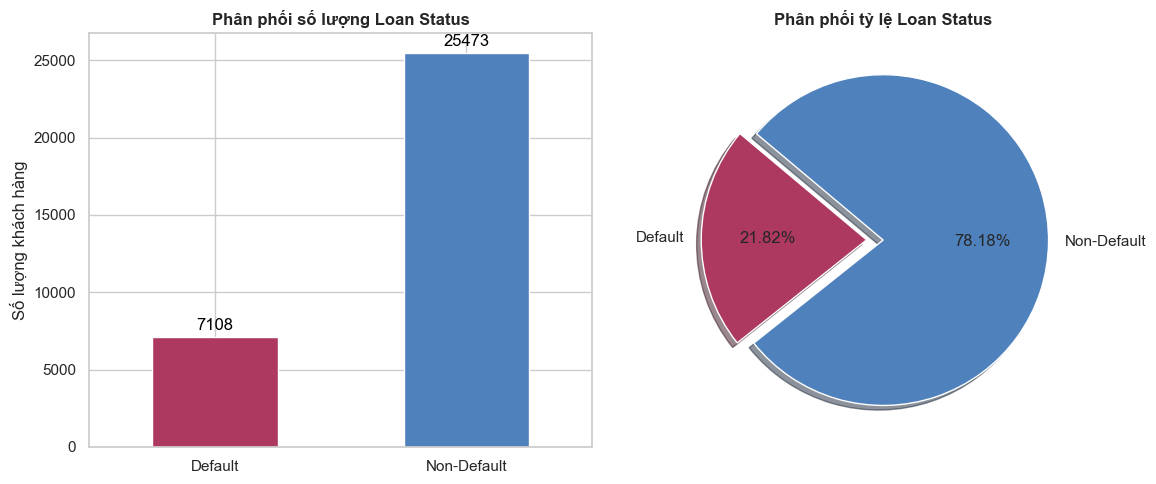

In [9]:
#tính số lượng
counts = df["loan_status_label"].value_counts()
counts = counts[['Default', 'Non-Default']]
colors = ["#AD3960", "#4F81BD"]    
# Tạo khung tranh 1 hàng, 2 cột
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


counts.plot(kind='bar', ax=ax[0], color=colors, rot=0) 

ax[0].set_title("Phân phối số lượng Loan Status", weight="bold")
ax[0].set_ylabel("Số lượng khách hàng")
ax[0].set_xlabel("")

#hiển thị thông số trên cột
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%d", padding=3, color="black")


counts.plot(kind='pie', ax=ax[1], colors=colors, autopct="%1.2f%%", 
            startangle=140, explode=(0.1, 0), shadow=True)

ax[1].set_title("Phân phối tỷ lệ Loan Status", weight="bold")
ax[1].set_ylabel("") 


plt.tight_layout()
plt.show()

Insight — Tỷ lệ default rate
- Nhóm chiếm tỷ lệ đa số: Non-Default (~78.18%) phần lớn khách hàng trở nợ dúng hạn  
- Nhóm số ít là Default (~21.82%) là thể hiển cho khách hàng có rủi ro cao  
- Dataset có mức mất cang bằng ở lớp trung bình , tỷ lệ khoảng 1-4   




## Biến số grade

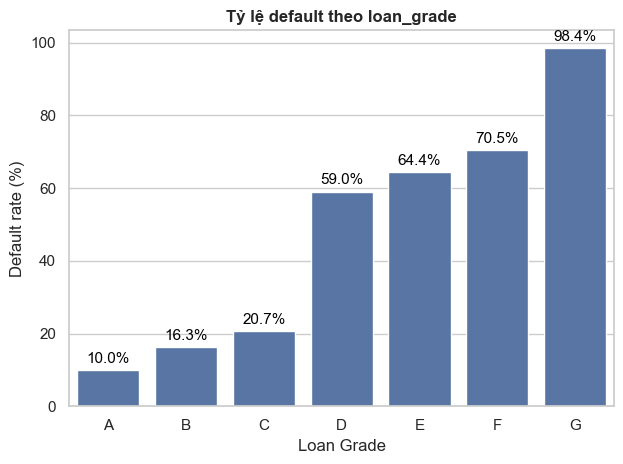

In [ ]:
grade = ( df.groupby("loan_grade")[target] 
    .agg(count="count", default_rate="mean")
    .reset_index()
)
grade["default_rate_pct"] = grade["default_rate"] * 100

ax = sns.barplot(
    data=grade,
    x="loan_grade",
    y="default_rate_pct",
    order=["A", "B", "C", "D", "E", "F", "G"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, color="black", fontsize=11)

plt.title("Tỷ lệ default theo loan_grade", weight="bold")
plt.xlabel("Loan Grade")
plt.ylabel("Default rate (%)")

plt.tight_layout()
plt.show()

Insight — Tỷ lệ default theo loan_grade  
- Default rate tăng mạnh theo thứ tự từ A → G:  
- Các nhóm A-C: có tỷ lệ default khá thấp  ư
- Các nhóm D-F : tăng dần với tye lệ default, nhận thấy rủi ro tăng cao hon
- Nhóm G: tỷ lệ default gần 100% cho thấy khách hàng nhóm này gần như không có khả năng trả nợ  


## Numerical feature

In [11]:
display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,1.440000e+02
person_income,32581.0,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
person_emp_length,31686.0,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,1.230000e+02
loan_amnt,32581.0,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,2.322000e+01
loan_to_income_ratio,32581.0,0.170553,0.107049,0.000789,0.089655,0.148148,0.229167,8.300000e-01
debt_to_income_ratio,32581.0,0.345208,0.129406,0.064502,0.251236,0.333188,0.423142,1.053888e+00
credit_utilization_ratio,32581.0,0.499884,0.259530,0.050001,0.275358,0.500289,0.725056,9.499980e-01
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,3.000000e+01
open_accounts,32581.0,8.042018,4.328087,0.000000,4.000000,8.000000,12.000000,1.500000e+01


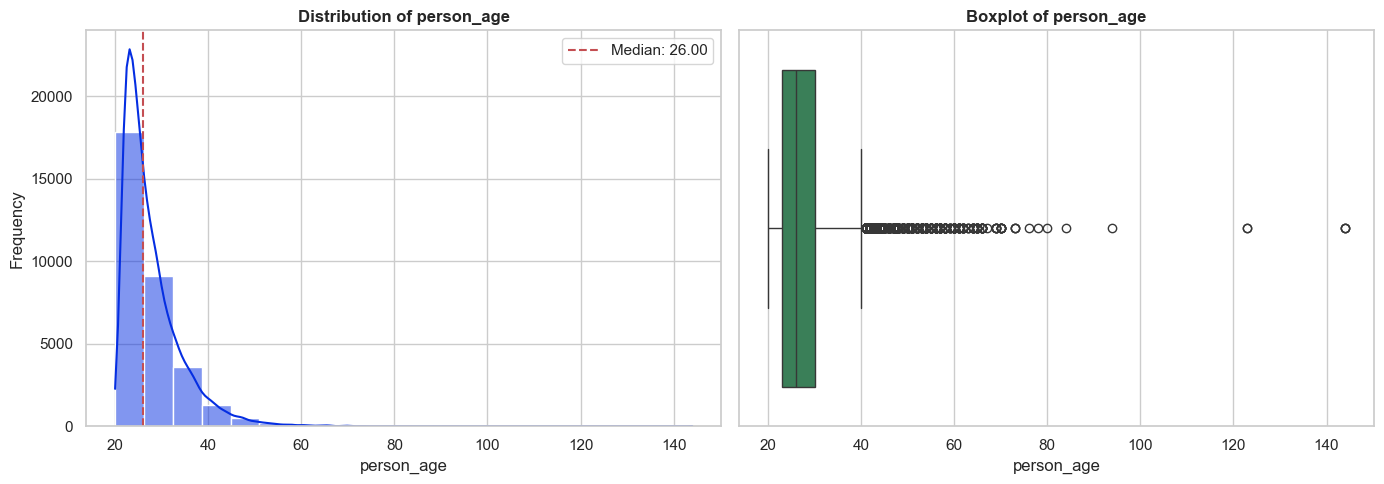

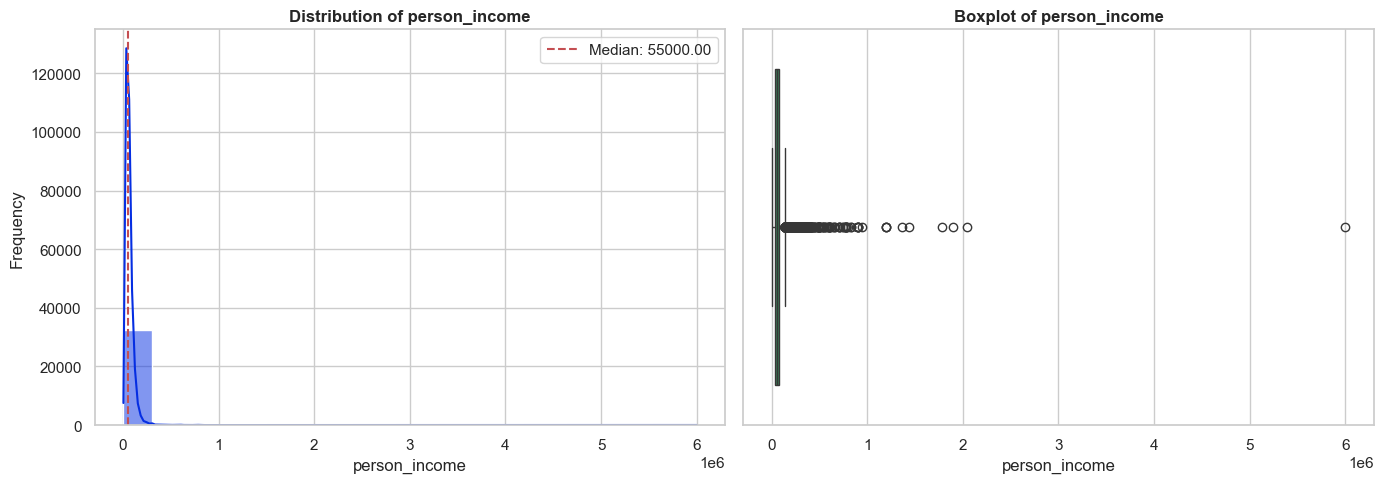

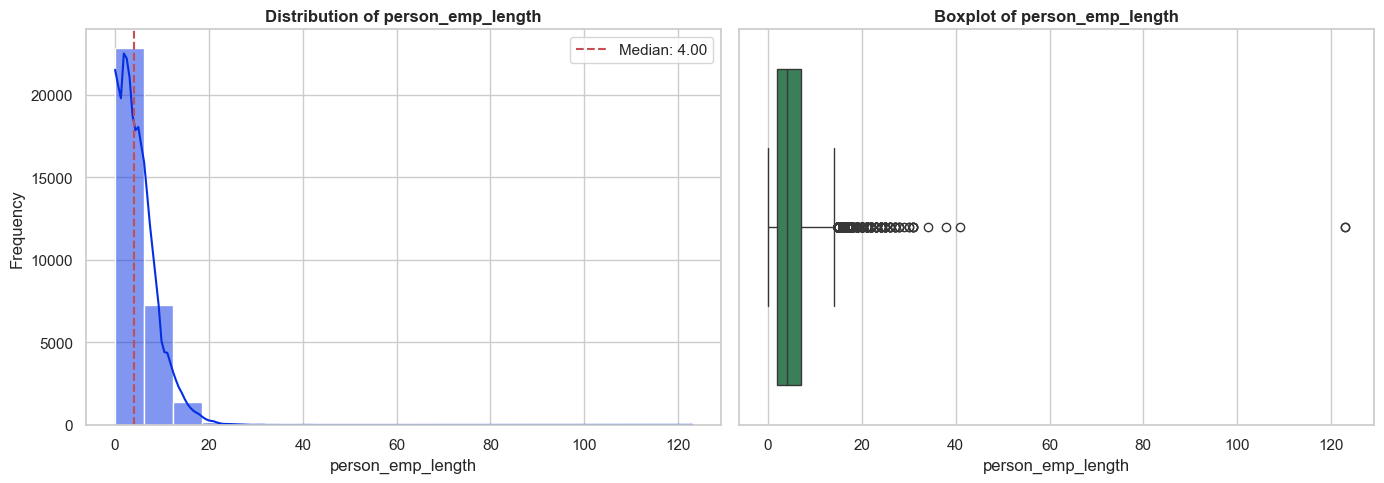

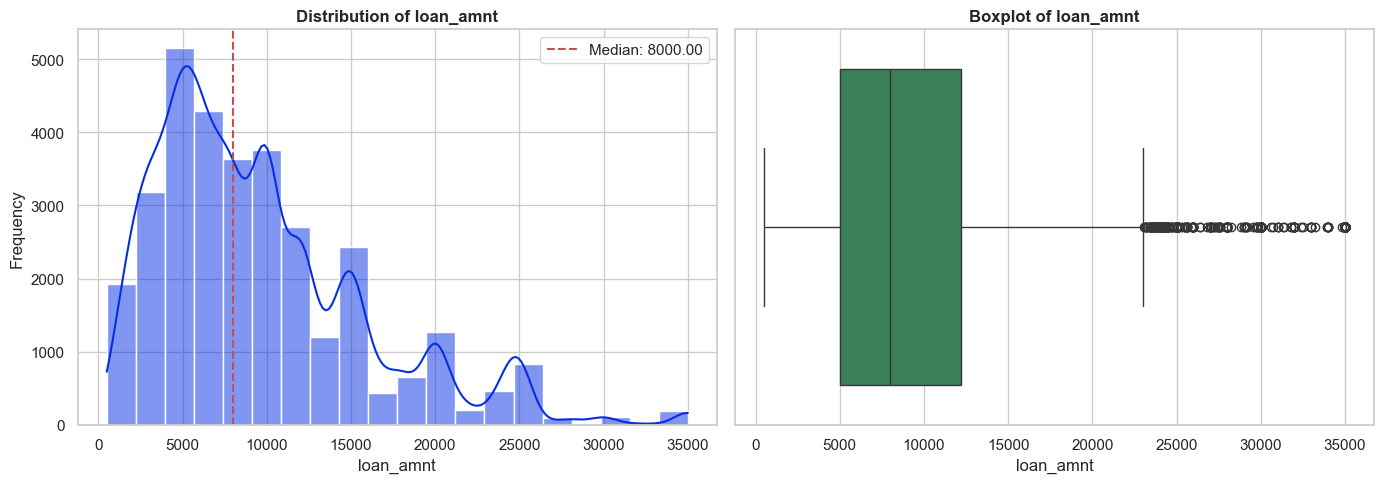

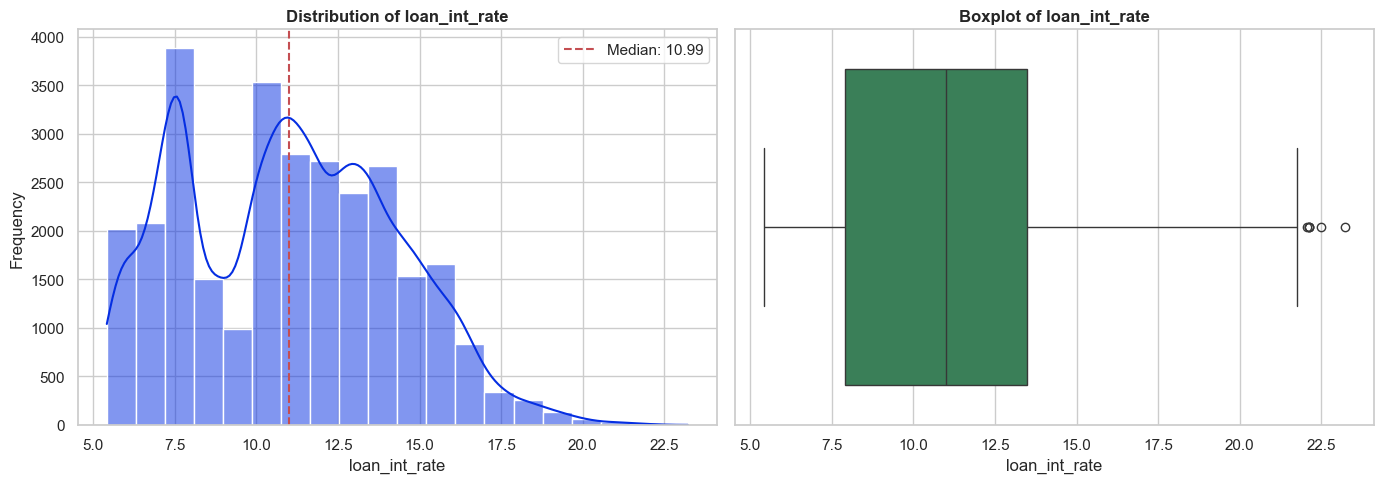

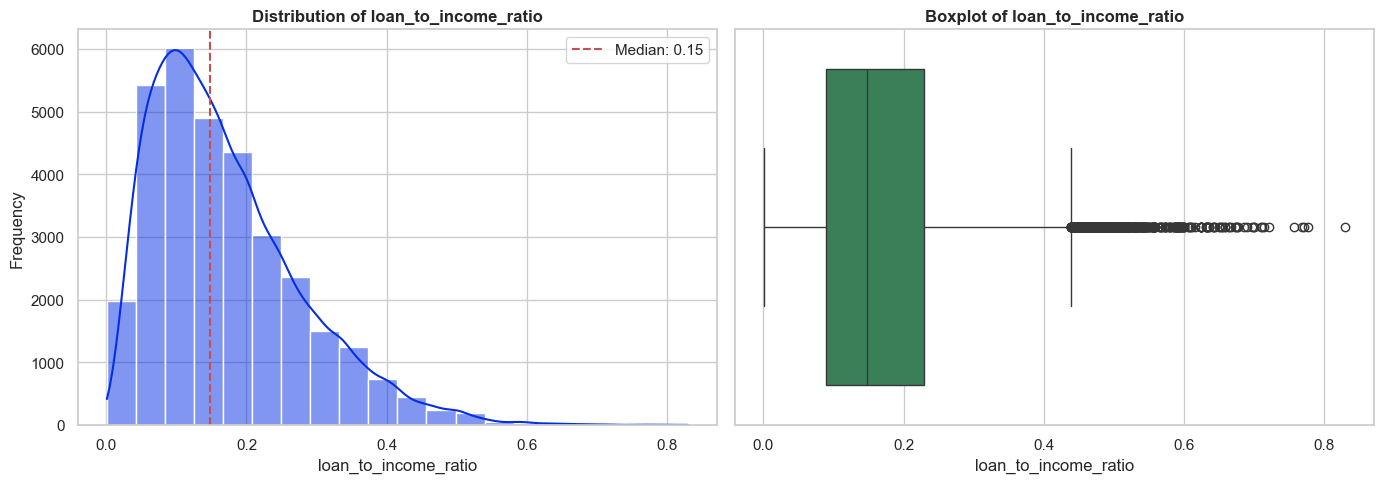

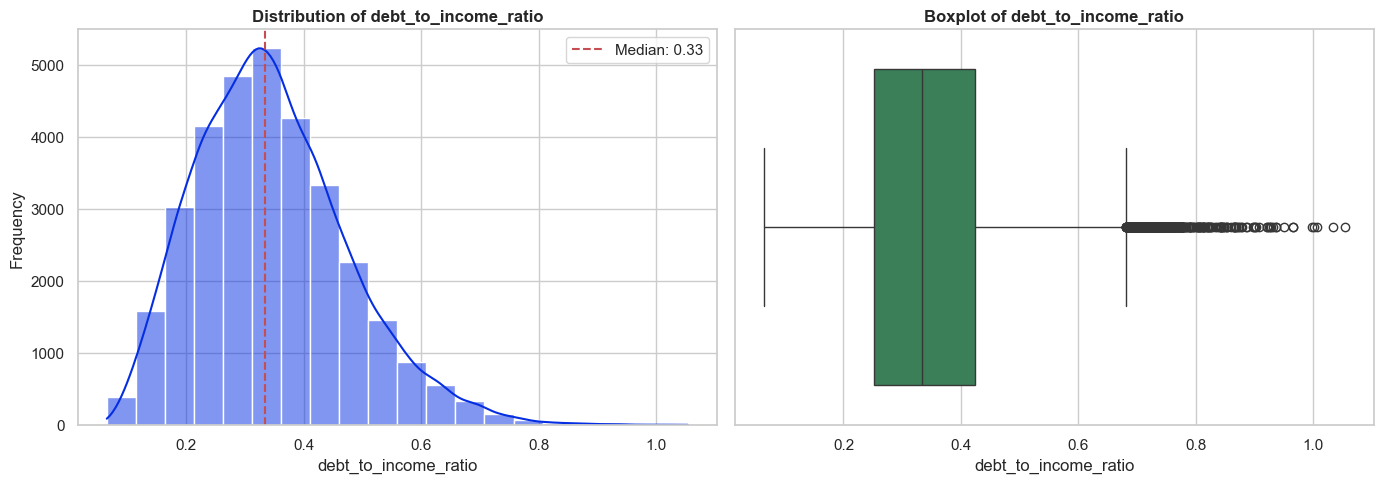

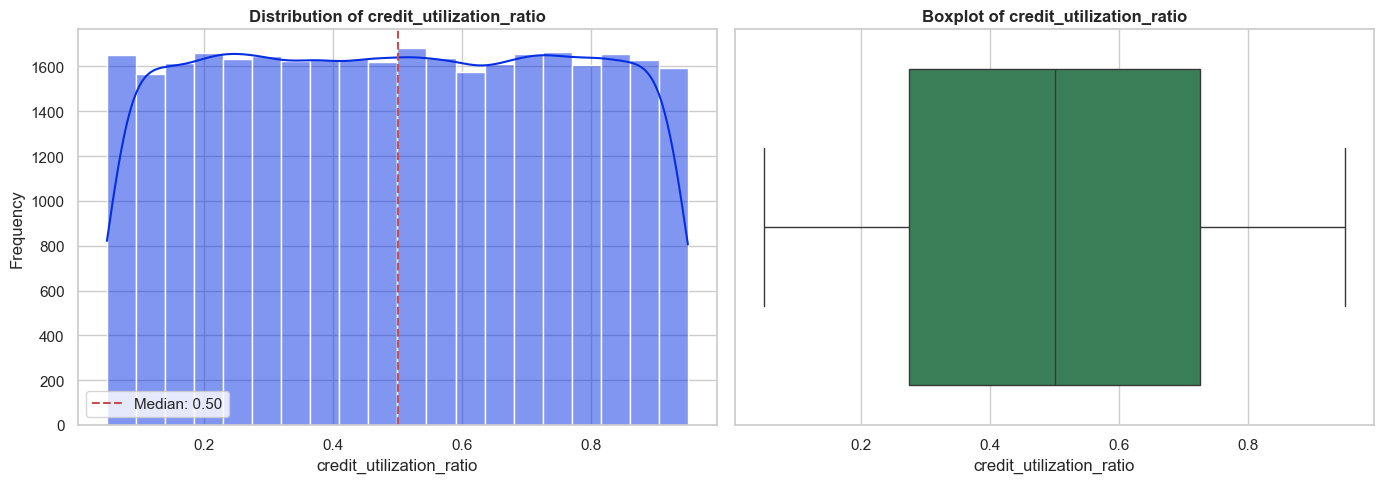

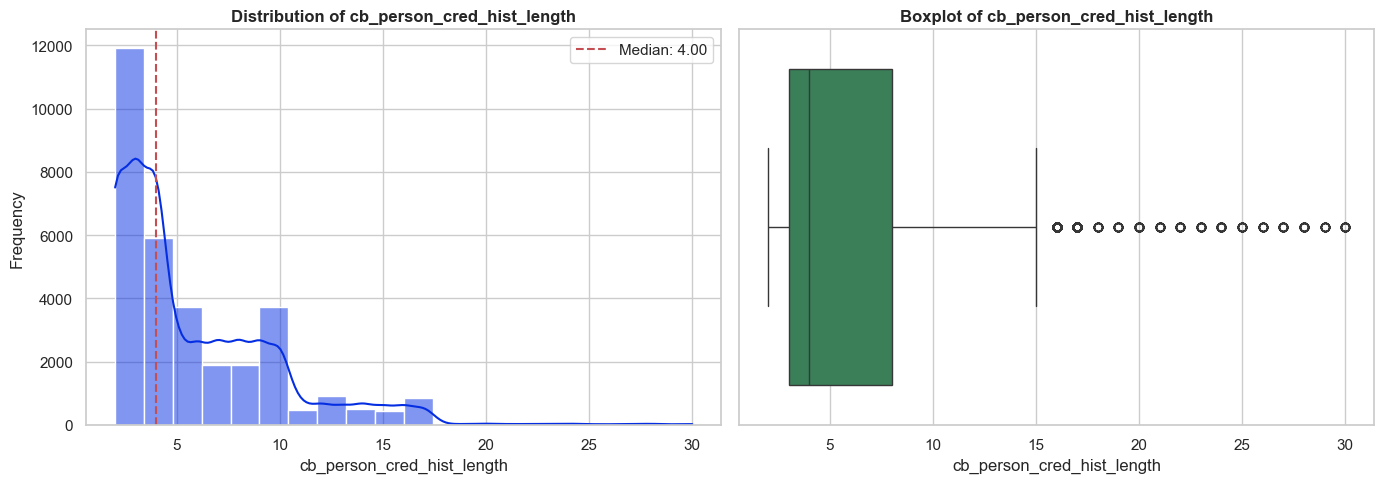

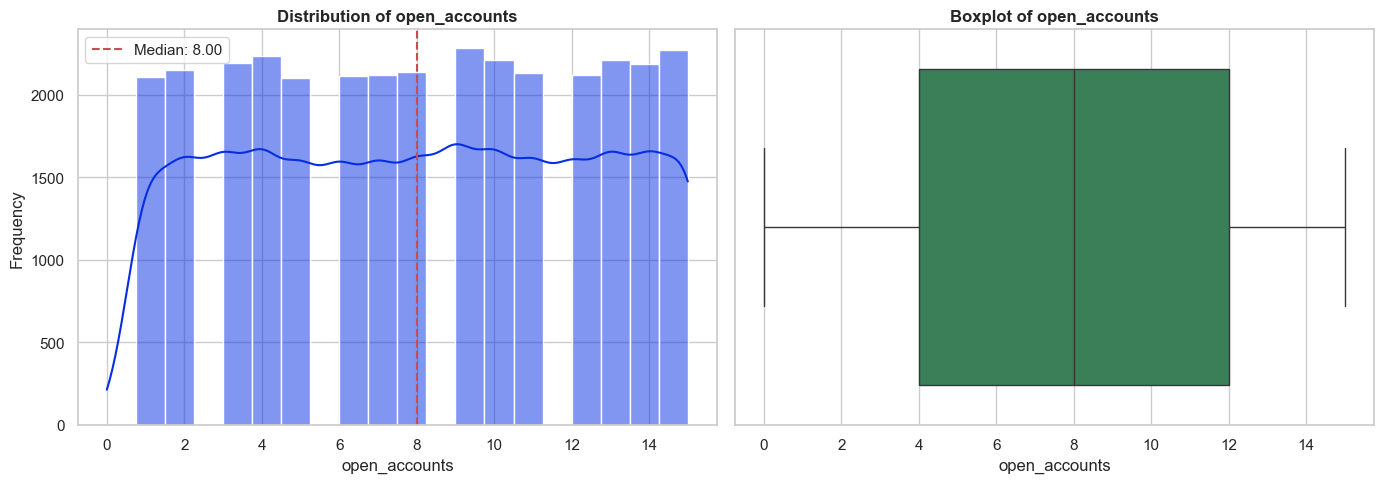

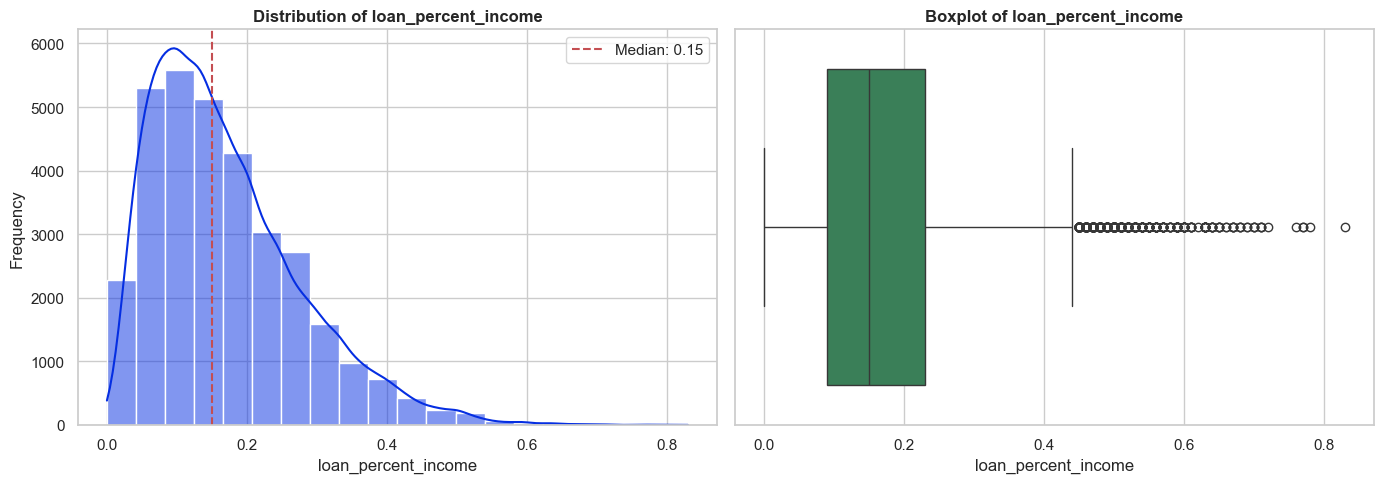

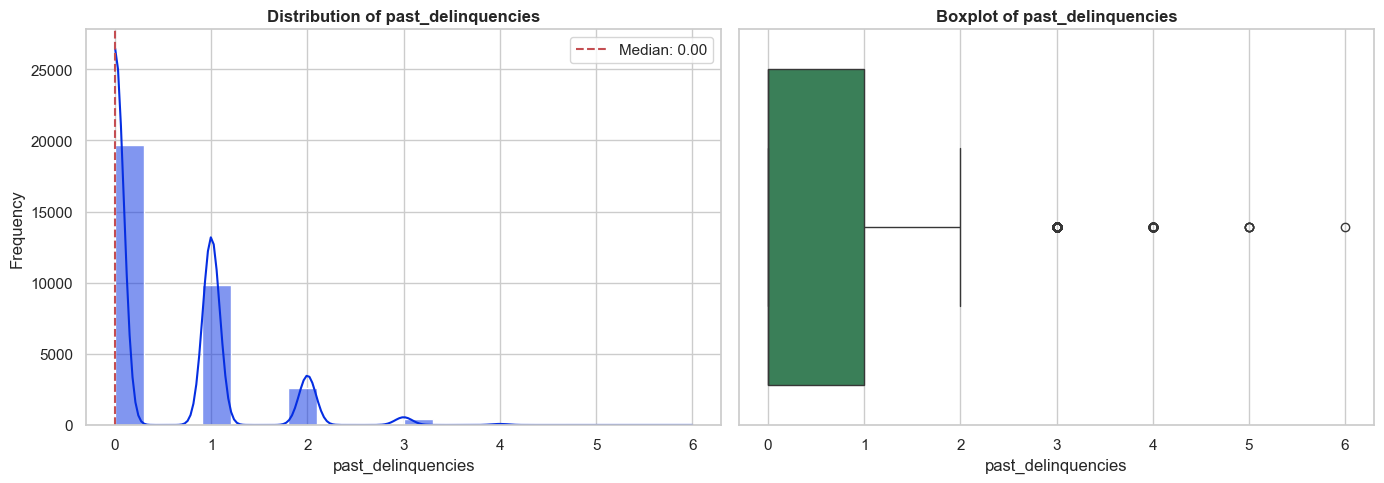

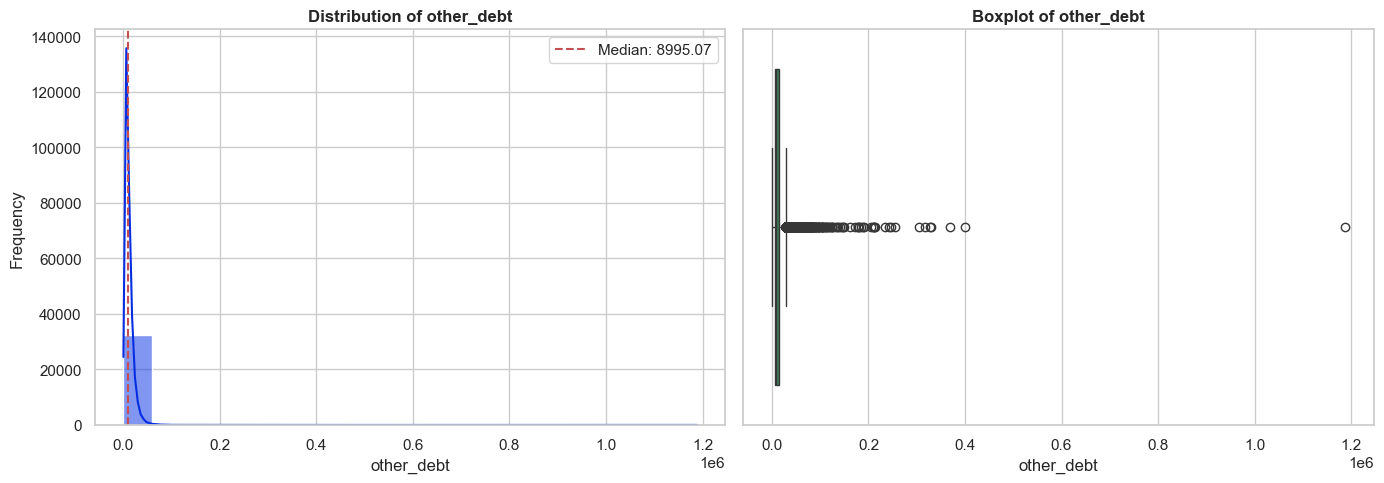

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

important_numeric = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "loan_percent_income",
    "past_delinquencies",
    "other_debt"
]

for col in important_numeric:
    
    # Tạo figure gồm 2 biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram 
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        color="#052EE2",
        ax=axes[0]
    )

    median_value = df[col].median()

    axes[0].axvline(
        median_value,
        color="#C44E52",
        linestyle="--",
        label=f"Median: {median_value:.2f}"
    )

    axes[0].set_title(f"Distribution of {col}", weight="bold", fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].legend()

    # Boxplot
    sns.boxplot(
        data=df,
        x=col,
        color="#2E8B57",
        ax=axes[1]
    )

    axes[1].set_title(f"Boxplot of {col}", weight="bold", fontsize=12)
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

In [13]:
# độ lệch (Skewness) cho danh sách biến số 
skew_df = pd.DataFrame(df[important_numeric].skew(), columns=['Skewness_Score'])
skew_df = skew_df.sort_values(by='Skewness_Score', ascending=False)

# dán nhãn mức độ nguy hiểm
def evaluate_skewness(score):
    if score > 1 or score < -1:
        return 'Lệch rất nặng'
    elif score > 0.5 or score < -0.5:
        return 'Lệch vừa'
    else:
        return 'Gần đối xứng'

skew_df['Action_Required'] = skew_df['Skewness_Score'].apply(evaluate_skewness)

skew_df.style.background_gradient(cmap='Reds', subset=['Skewness_Score'])

,Skewness_Score,Action_Required
person_income,32.865349,Lệch rất nặng
other_debt,28.461944,Lệch rất nặng
person_emp_length,2.614455,Lệch rất nặng
person_age,2.581393,Lệch rất nặng
cb_person_cred_hist_length,1.661790,Lệch rất nặng
past_delinquencies,1.397332,Lệch rất nặng
loan_amnt,1.192477,Lệch rất nặng
loan_to_income_ratio,1.065064,Lệch rất nặng
loan_percent_income,1.064669,Lệch rất nặng
debt_to_income_ratio,0.619493,Lệch vừa


 -phân tích độ lệch   
Skewness hay còn gọi là độ lệch trong thống kê, là chỉ số cho biết mức độ bất đối xứng của một phân phối dữ liệu so với phân phối chuẩn. 
- skew~0: đối xứng: Mean= Median = Mode
- skew >0: lệch phải : Mean > Median > Mode
- skew <0 : lệch trái: Mean < Median




--INSIGHT Numerical feature
- Phần lớn các biến số trong tập dữ liệu đều lệch phải(right-skewed) , cho thấy giá trị tập trung ở mức thấp, với đuôi dài và nhiều giá trị ngoại lai lớn.
- 8 trên 12 biến có độ lệch đáng kể (|skew| > 0.5), cho thấy phần lớn dữ liệu không tuân theo phân phối chuẩn.
- Các biến như person_income và other_debt có độ lệch cực lớn (skew > 25), cho thấy tồn tại outliers rất lớn và phân phối có đuôi rất dày.
- Các biến lệch vừa như debt_to_income_ratio cho thấy có mất cân bằng, nhưng không nghiêm trọng như các biến về giá trị tiền.
- Các biến như loan_int_rate, open_accounts, và credit_utilization_ratio có phân phối gần đối xứng, nên ổn định hơn khi đưa vào mô hình.
- Nhiều biến lệch phải và có outlier rõ: person_income, loan_amnt, person_age, person_emp_length, loan_to_income_ratio, debt_to_income_ratio.
- credit_utilization_ratio và open_accounts phân bố khá đều, khả năng phân tách rủi ro độc lập không quá mạnh. 
- Dữ liệu lệch phải nhiều vì các biến tài chính trong thực tế thường có phân phối dương, không đồng đều và có đuôi dài với một số giá trị cực lớn.Từ đó rút ra rằng dữ liệu cần được kiểm tra outlier, xem xét biến đổi phân phối và có thể chia band trước khi phân tích sâu hoặc đưa vào mô hình.
- Các biến như loan_int_rate, open_accounts, và credit_utilization_ratio có phân phối gần đối xứng, do đó ổn định hơn cho việc xây dựng mô hình. 
- Sự lệch mạnh ở các biến tài chính phản ánh hành vi thực tế, khi chỉ một số ít khách hàng có thu nhập hoặc mức nợ rất cao.  
 =>Dữ liệu tài chính có phân phối lệch mạnh là điều bình thường trong thực tế. Tuy nhiên, cần xử lý (transform) các biến lệch nặng để đảm bảo mô hình học tốt và ổn định hơn.


## Categorical Variables

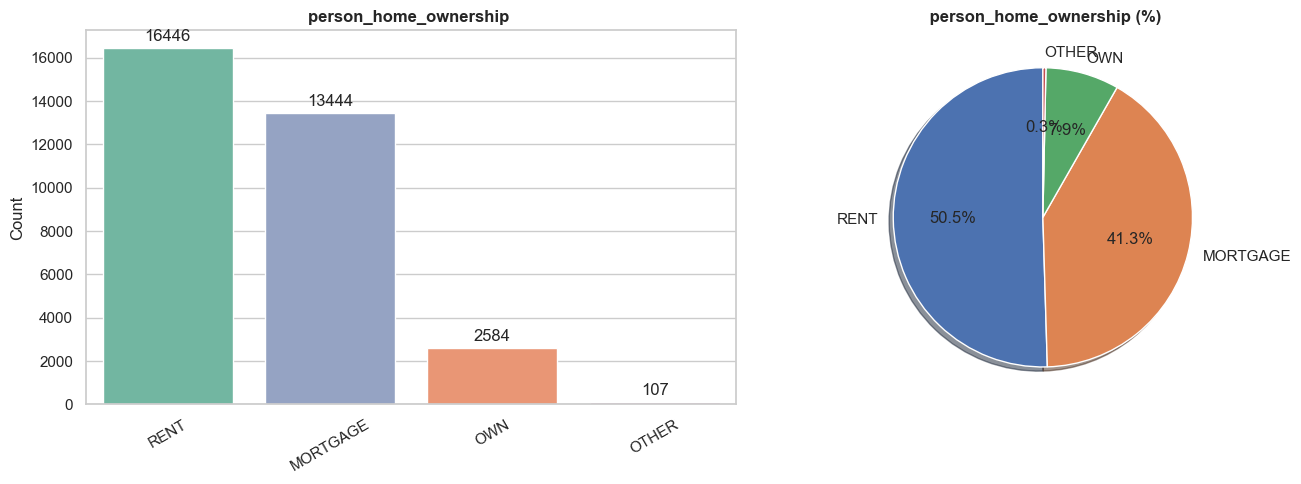

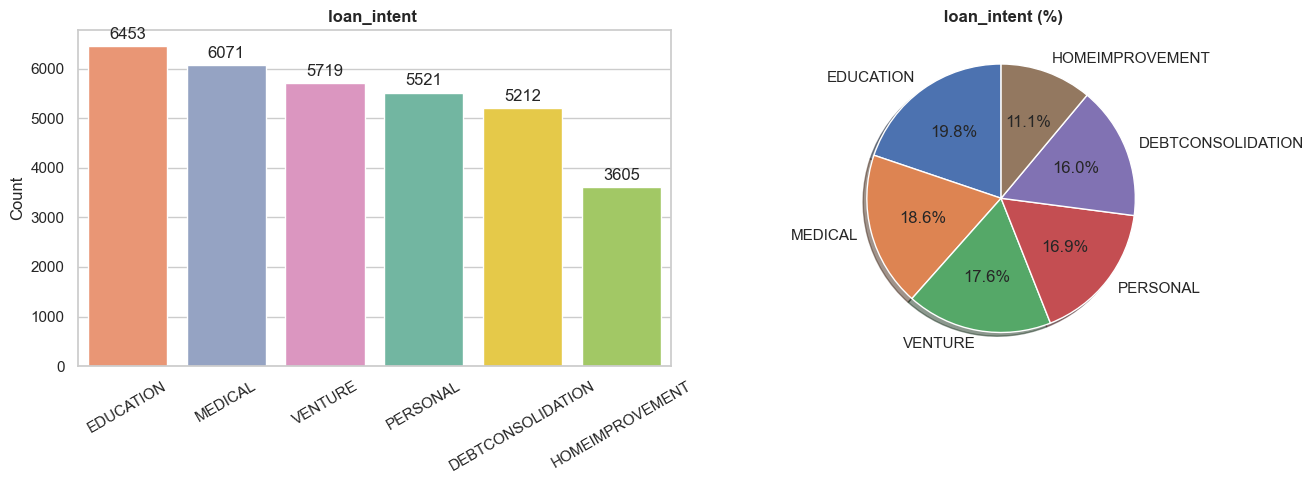

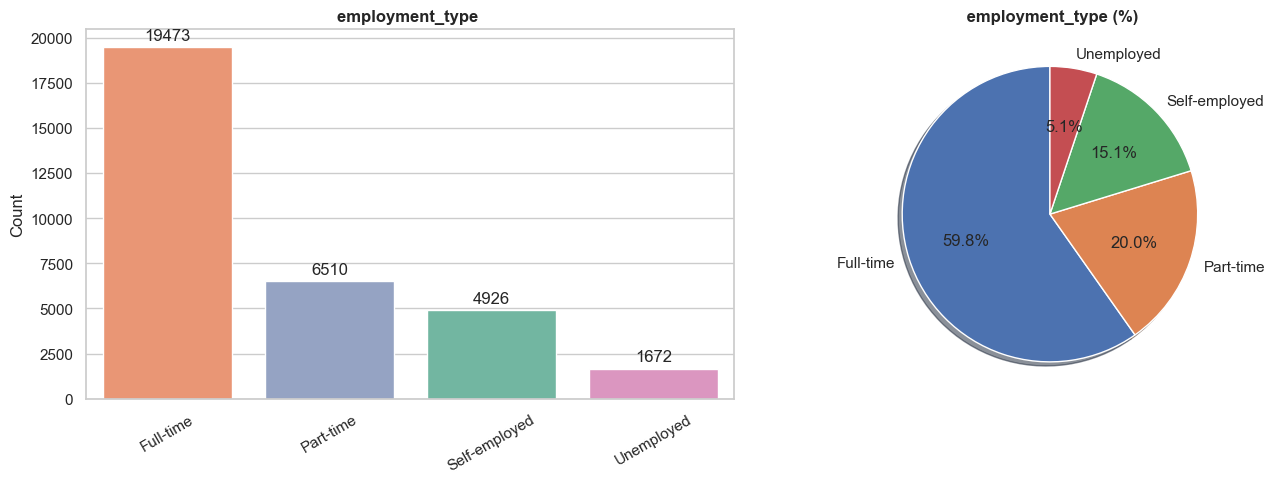

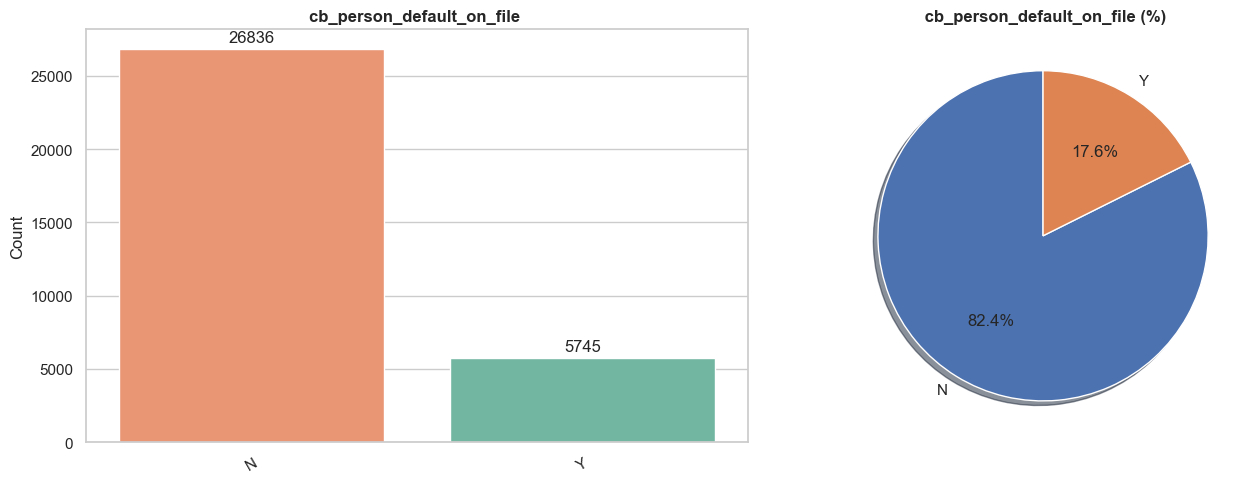

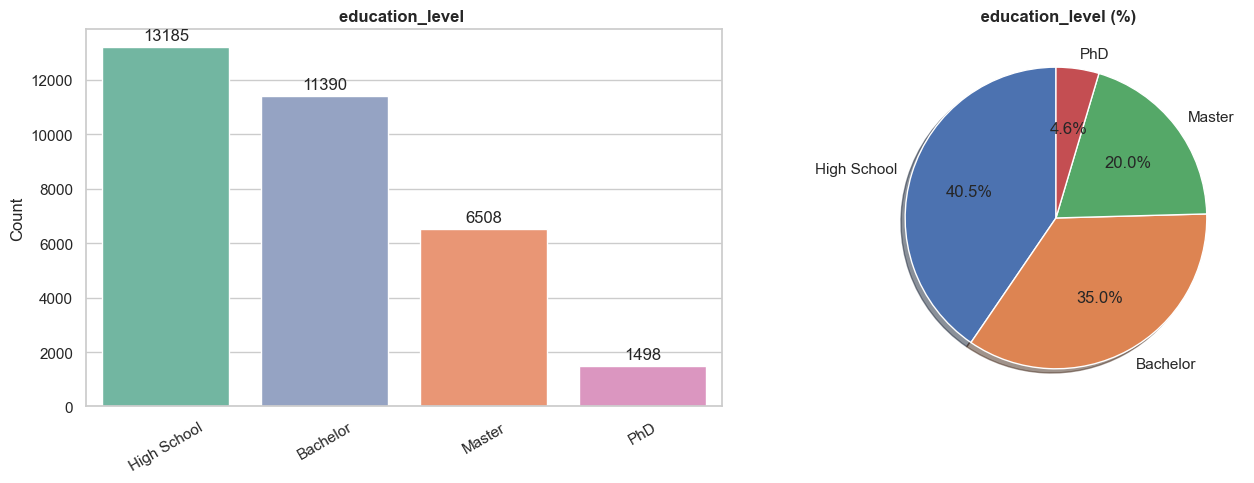

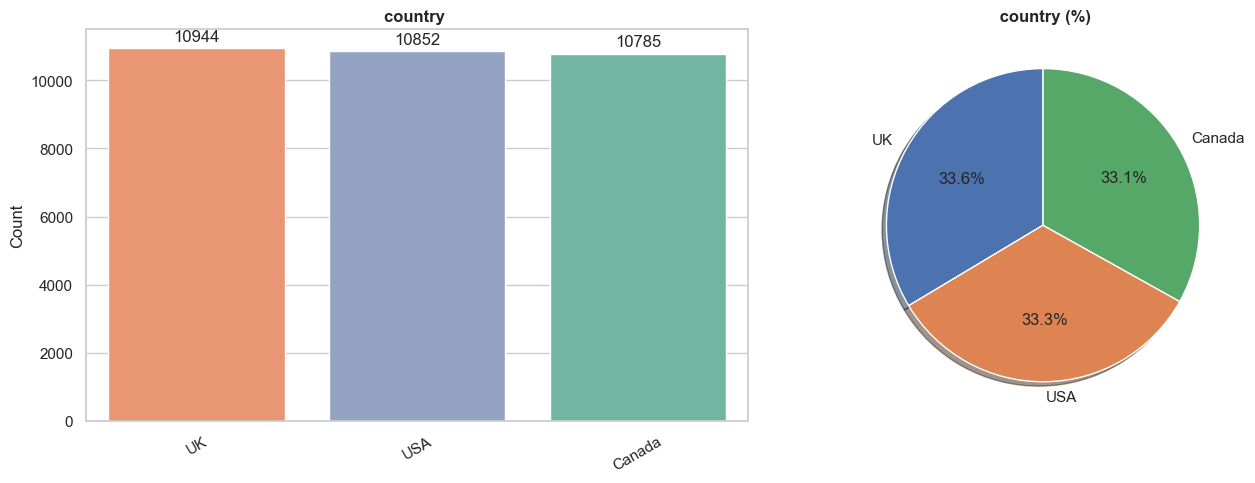

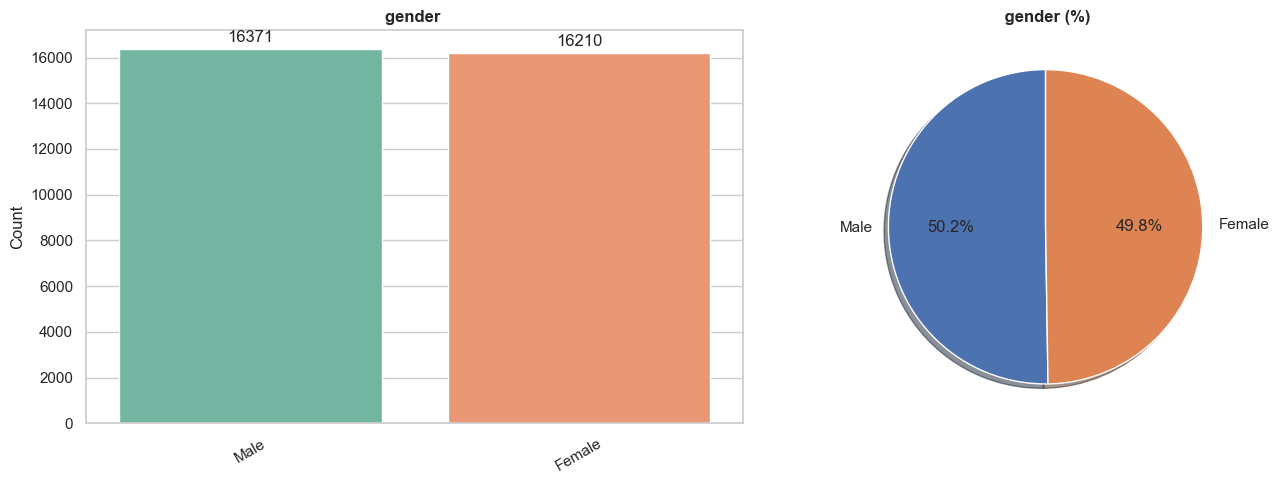

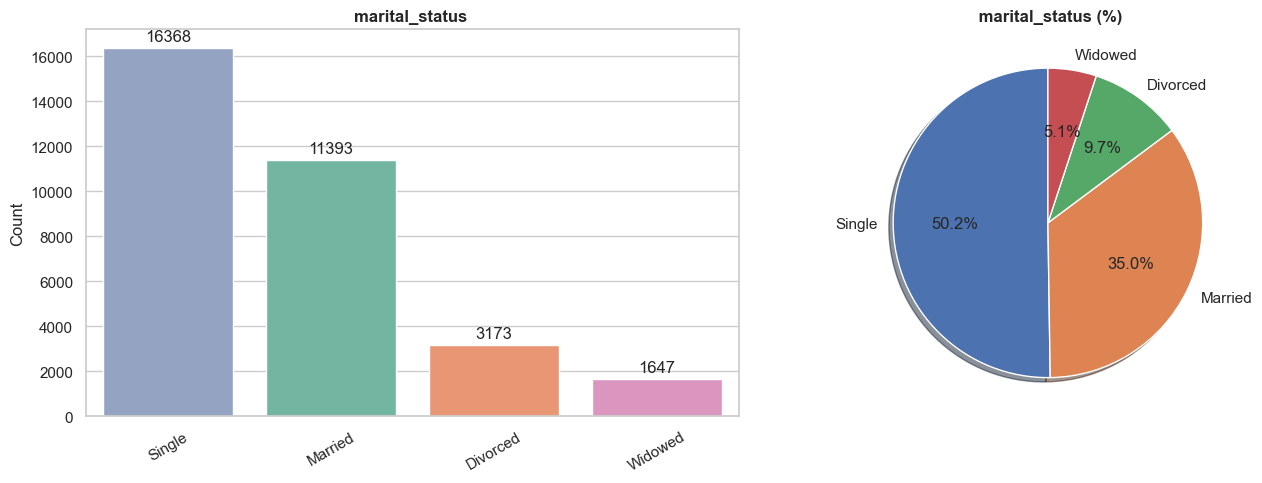

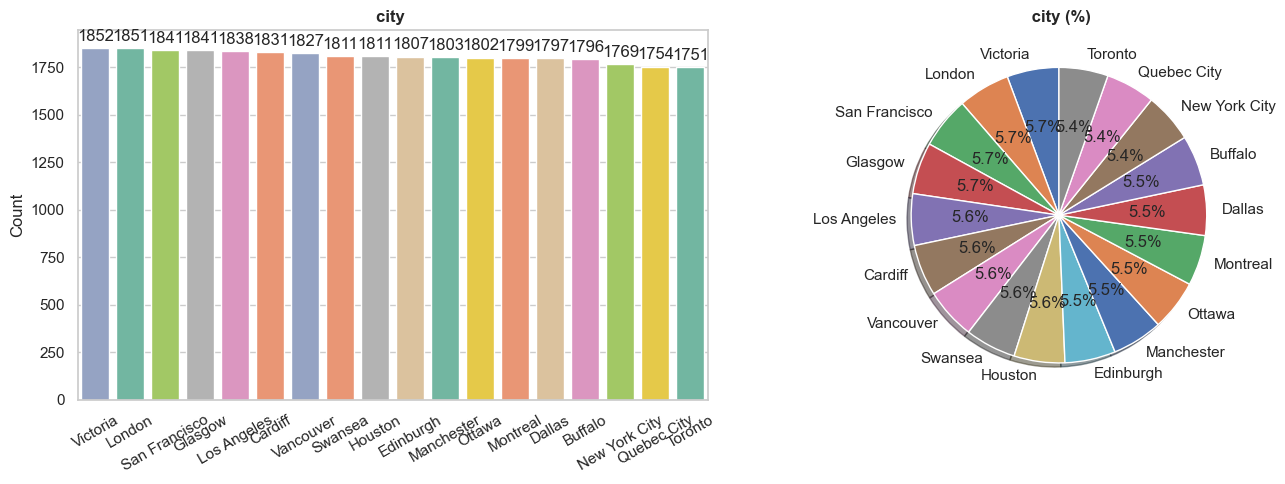

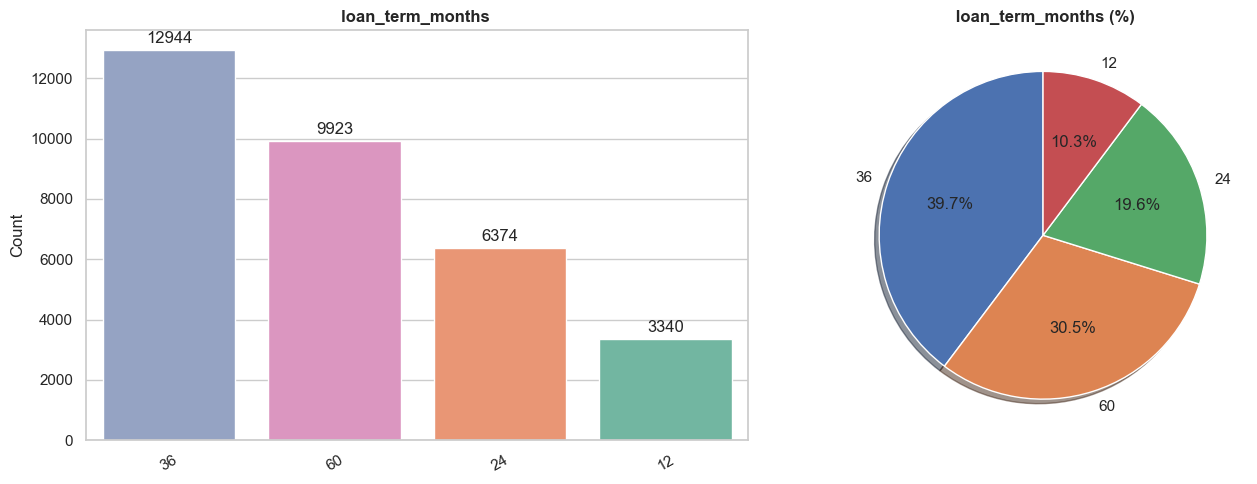

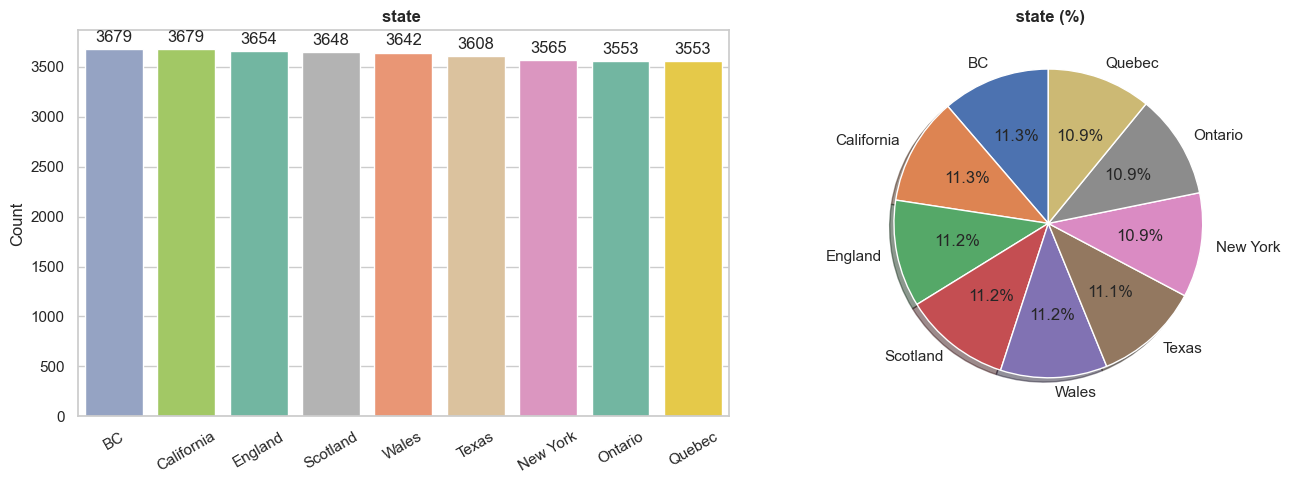

In [14]:

cat_features = [
    "person_home_ownership",
    "loan_intent",
    "employment_type",
    "cb_person_default_on_file",
    "education_level",
    "country",
    "gender",
    "marital_status",
    "city",
    "loan_term_months",
    "state"
]

# Bắt đầu vòng lặp
for col in cat_features:
    
    # Tính tần suất
    value_counts = df[col].value_counts()
    value_order = value_counts.index

    # Tạo figure gồm 2 biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Biểu đồ cột bên trái
    ax1 = sns.countplot(
        data=df,
        x=col,
        order=value_order,
        palette="Set2",
        hue=col,
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title(f"{col} ", weight="bold", fontsize=12)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30)

    # Gắn số lên đầu cột
    for container in ax1.containers:
        ax1.bar_label(container, padding=3)

    #Pie chart
    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        shadow=True
    )

    axes[1].set_title(f" {col} (%)", weight="bold", fontsize=12)

    plt.tight_layout()
    plt.show()

 INSIGHT
- chủ yếu gồm khách hàng không sở hữu nhà, với phần lớn là RENT (~50%) hoặc MORTGAGE (~41%), cho thấy mức độ đòn bẩy tài chính ở mức trung bình. 
- Mục đích vay được phân bổ khá đồng đều, trong đó education, medical và venture là phổ biến nhất (~17–20% mỗi loại), phản ánh nhu cầu vay đa dạng.
- hầu hết khách hàng không có lịch sử vỡ nợ trước đó (~82%), cho thấy tập khách hàng nhìn chung đáng tin cậy.
- Khách hàng độc thân (~50%) chiếm đa số, tiếp theo là đã kết hôn (~35%), phản ánh sự khác biệt về trách nhiệm tài chính giữa các nhóm.
- Phần lớn khách hàng có trình độ học vấn trung bình, với High School (~40%) và Bachelor (~35%) là phổ biến nhất.
- kỳ hạn khoản vay tập trung ở 36 tháng(~40%) và 60 tháng(~31%) cho thấy khách hàng ưu tiên thời gian tổng thời gian trả thay vì thời gian giắn hạn để giảm lãi suất.
- Lao động toàn thời gian (~60%) chiếm ưu thế, cho thấy đa số khách hàng có nguồn thu nhập ổn định.
- Về địa lý, dữ liệu được phân bổ đồng đều giữa các quốc gia (UK, USA, Canada), đảm bảo tính đại diện vùng miền cân bằng
- Phân bố theo bang (state) và thành phố (city) tương đối đồng đều, không có sự tập trung địa lý rõ rệt.
- Phần lớn khách hàng không có lịch sử trễ hạn (~60%), trong khi một phần nhỏ (~30%) chỉ có 1 lần trễ hạn, cho thấy hành vi trả nợ nhìn chung khá tốt.

Phân tích hai biến

Numeric × Target  
mật độ density : S(1)= X x Y   



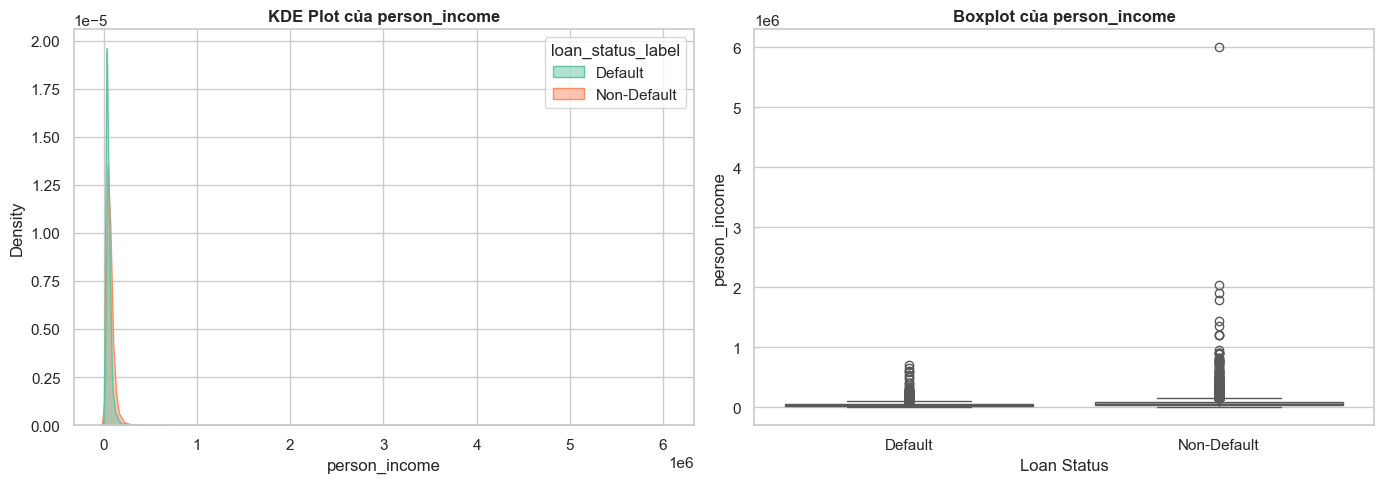

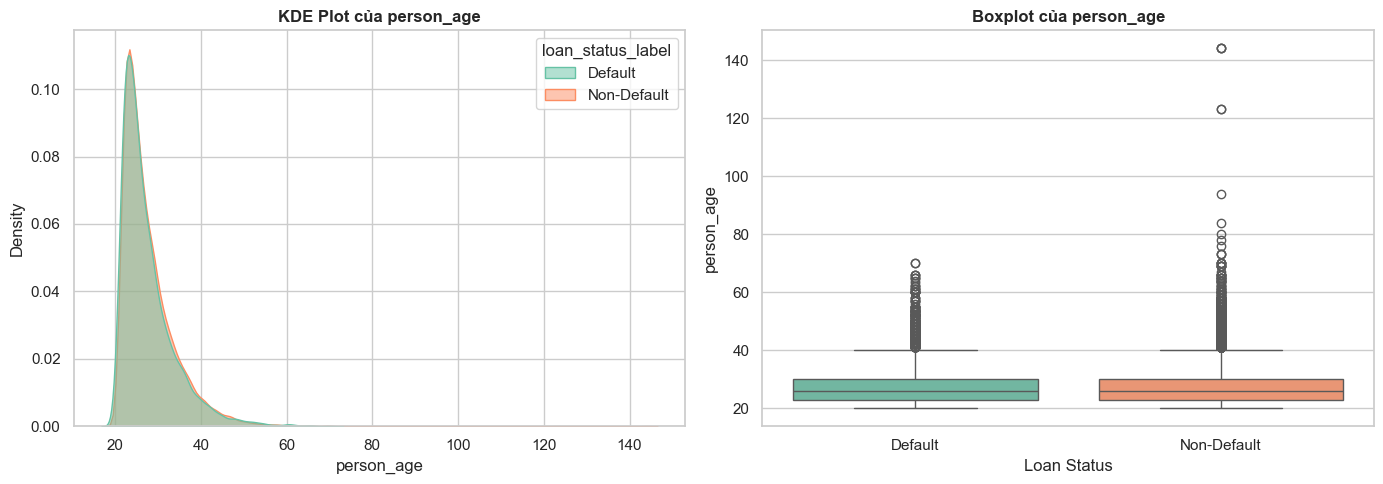

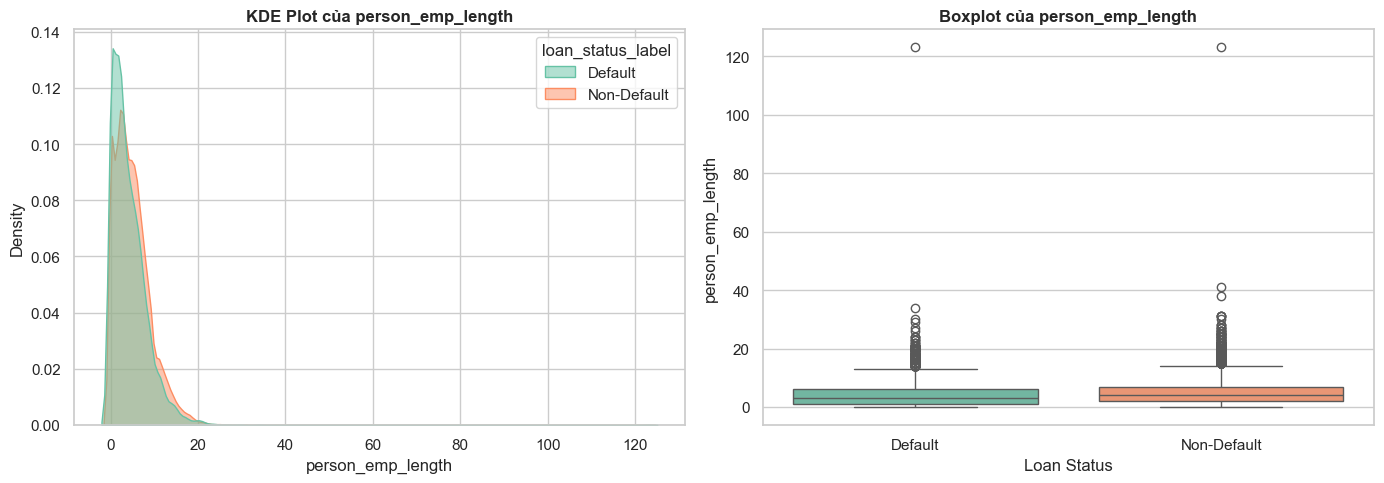

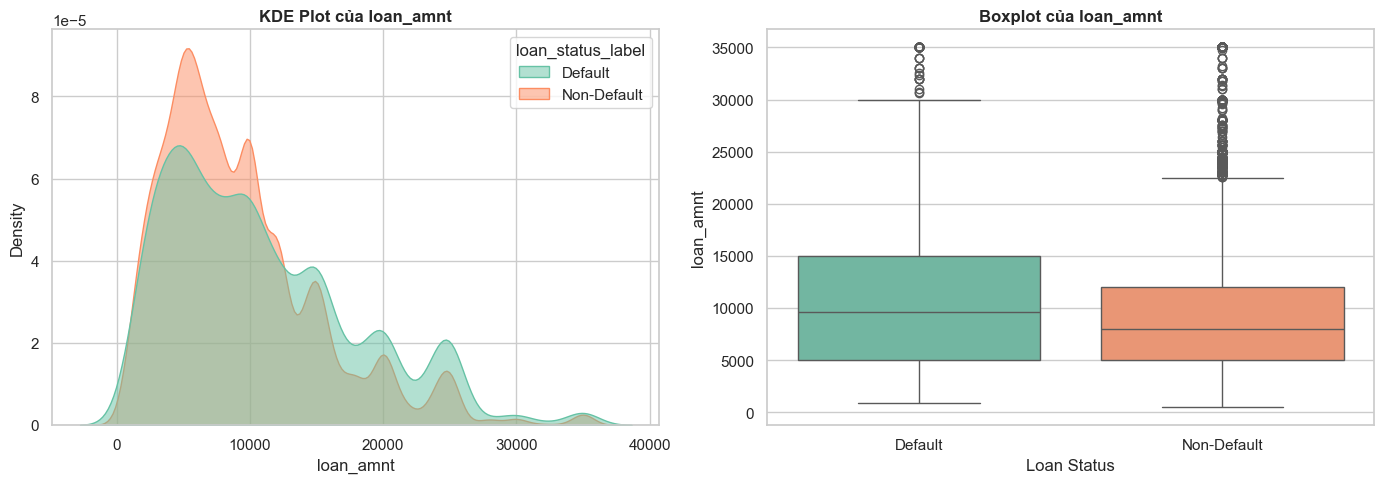

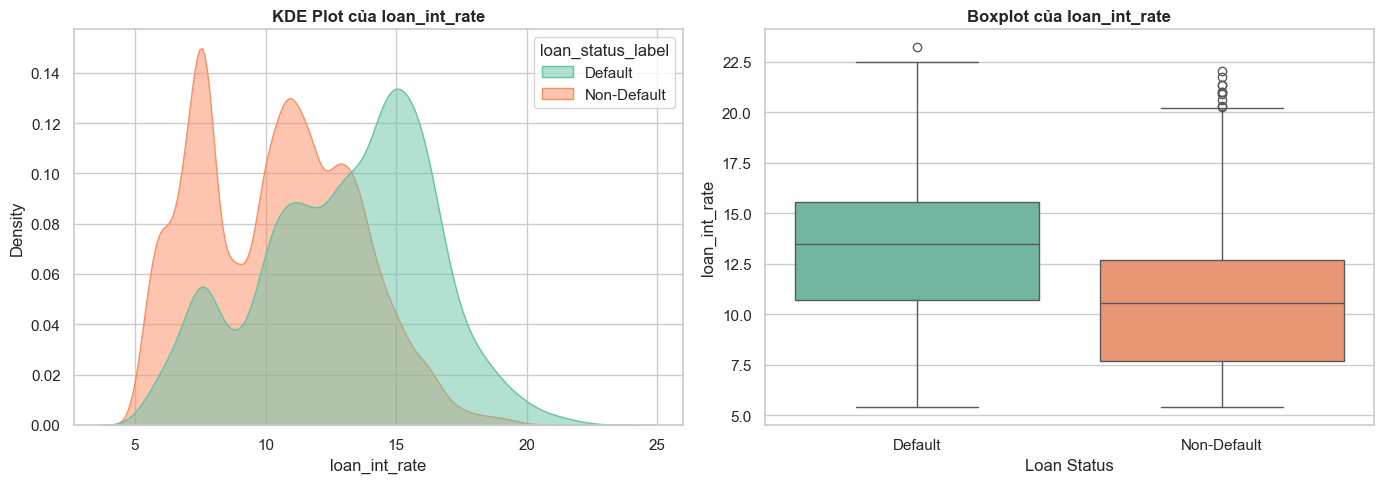

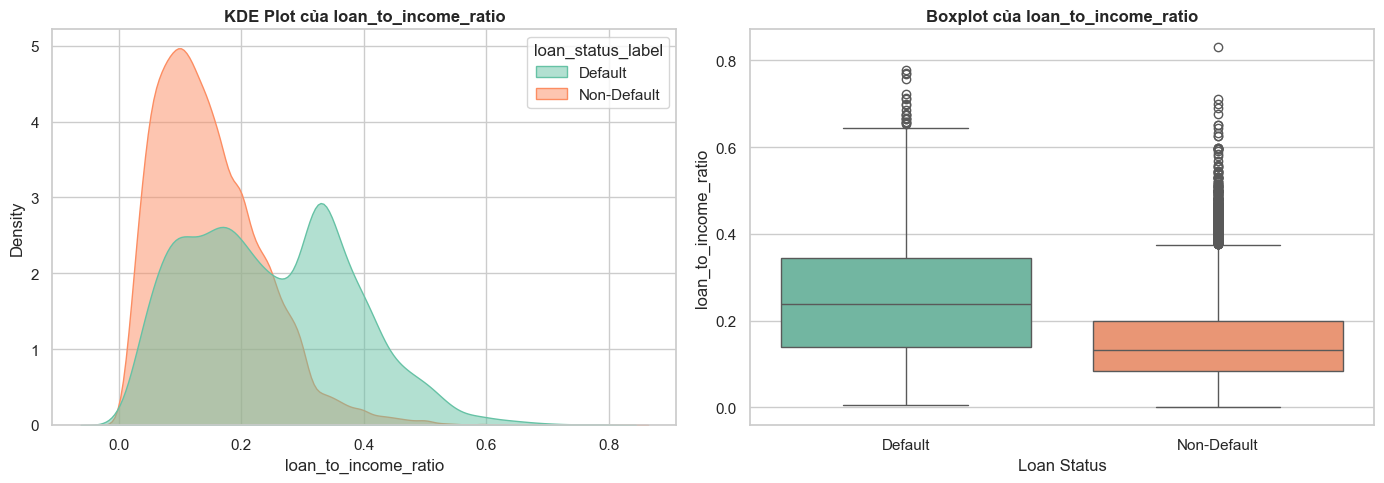

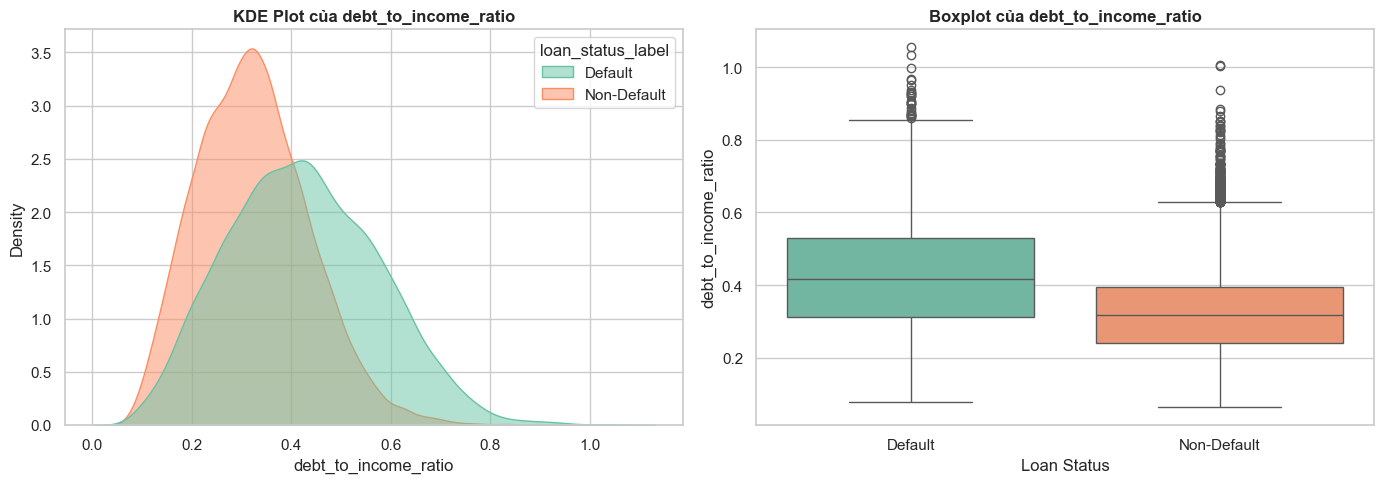

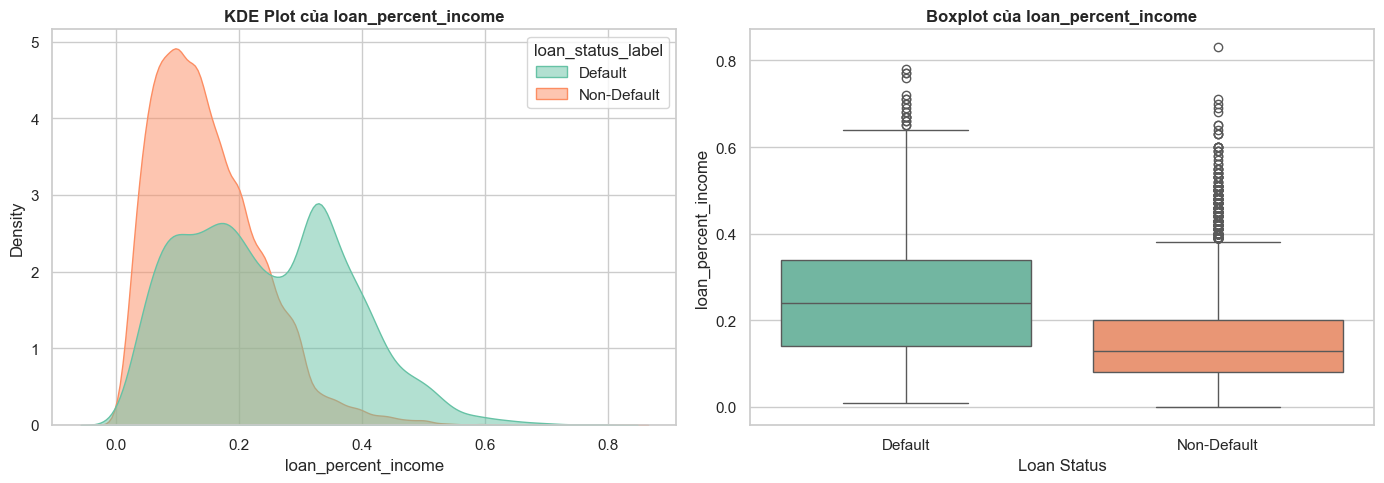

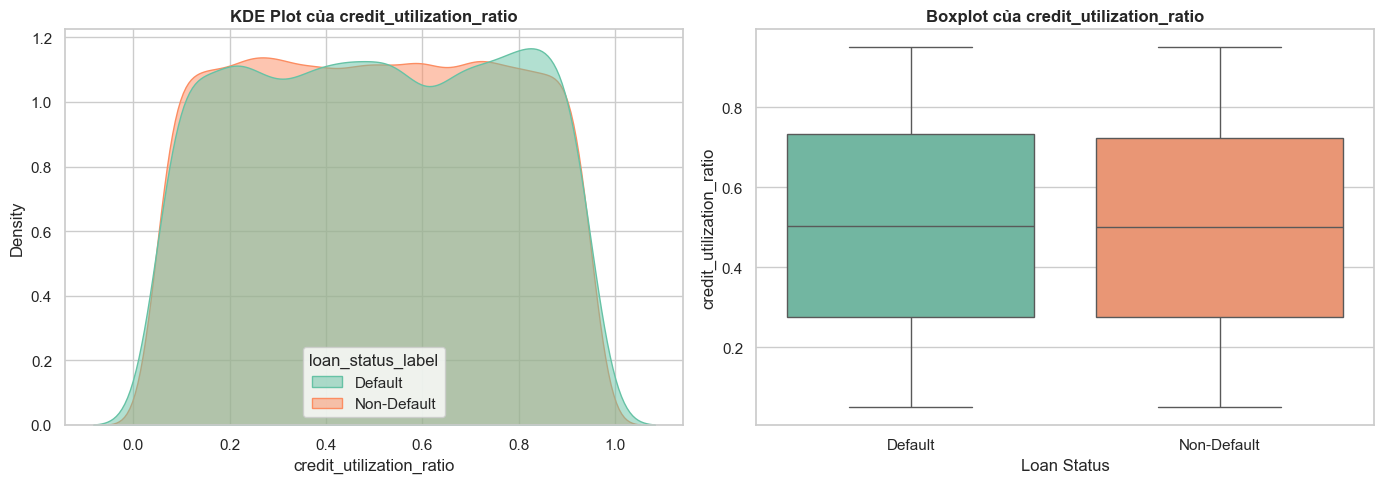

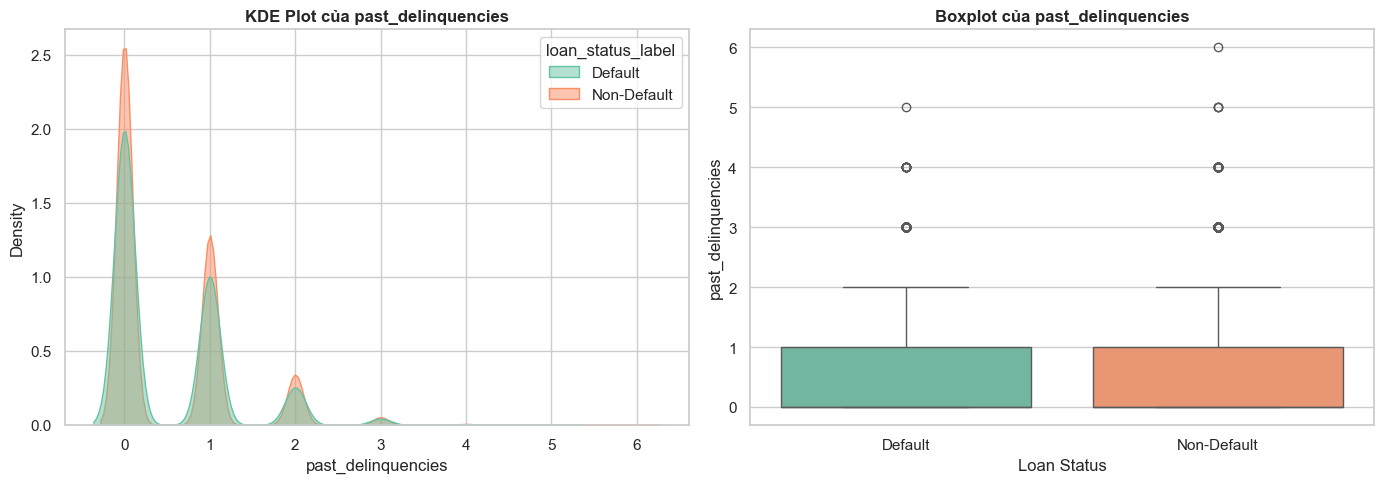

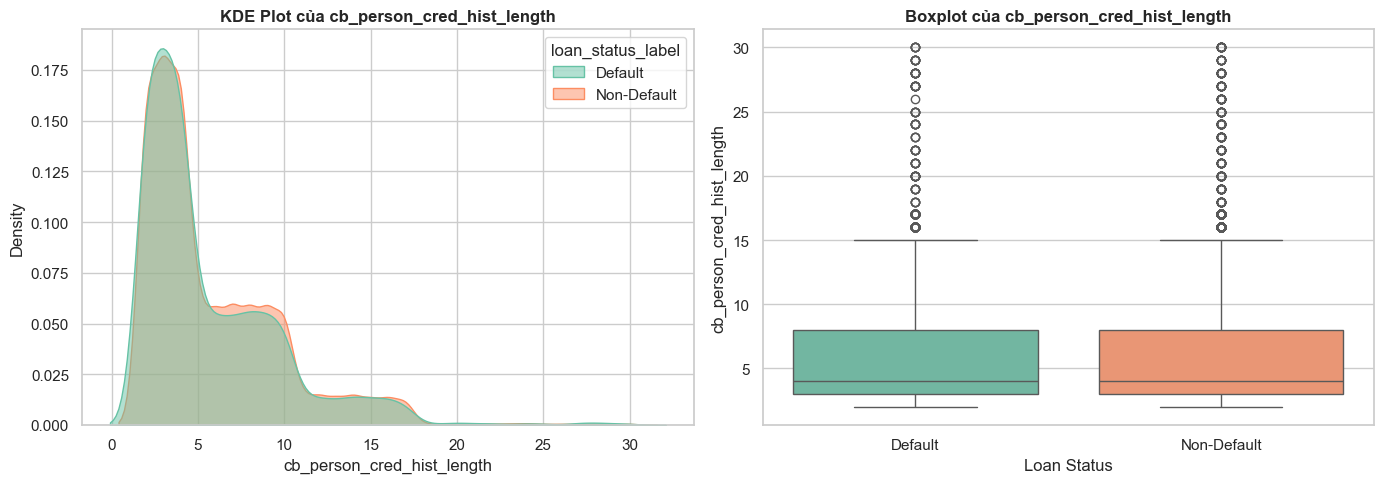

In [ ]:
important_numeric = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "loan_percent_income",
    "credit_utilization_ratio",
    "past_delinquencies",
    "cb_person_cred_hist_length"
]

for col in important_numeric:
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #  KDE plot
    sns.kdeplot(
        data=df,
        x=col,
        hue="loan_status_label",
        fill=True,
        common_norm=False,
        palette="Set2",
        alpha=0.5,
        ax=axes[0]
    )
    axes[0].set_title(f"KDE Plot của {col}", weight="bold", fontsize=12)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")

    # Boxplot
    sns.boxplot(
        data=df,
        x="loan_status_label",
        y=col,
        palette="Set2",
        hue="loan_status_label",
        ax=axes[1]
    )
    axes[1].set_title(f"Boxplot của {col}", weight="bold", fontsize=12)
    axes[1].set_xlabel("Loan Status")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()
    plt.close()

 INSIGHT
- loan_int_rate: một trong những biến phân tách tốt nhất. Nhóm Default tập trung rõ hơn ở vùng lãi suất cao, trong khi nhóm Non-default nghiêng về mức lãi suất thấp hơn. Boxplot xác nhận median của default cao hơn đáng kể.
- LTI: phân phối Default có tỷ lệ vay trên thu nhập cao hơn rõ rệt. Điều này phản ánh rằng khi khoản vay chiếm tỷ trọng lớn so với thu nhập, khả năng trả nợ sẽ giảm. KDE và boxplot đều cho thấy sự dịch chuyển sang vùng rủi ro cao.
- DTI: phân phối Default có DTI cao hơn, trong khi Non-default tập trung ở vùng thấp hơn. Điều này cho thấy gánh nặng nợ càng cao thì rủi ro default càng lớn.
- person_income: Nhóm Non-default có xu hướng nằm ở vùng thu nhập cao hơn, trong khi nhóm Default tập trung nhiều hơn ở vùng thu nhập thấp. Điều này cho thấy thu nhập là tín hiệu quan trọng phản ánh khả năng trả nợ. Boxplot cũng cho thấy hai nhóm có sự khác biệt về trung vị, dù vẫn có outlier rất lớn ở cả hai phía.
- loan_amnt: phân phối Default có xu hướng vay khoản tiền lớn hơn và phân phối trải rộng hơn về phía giá trị cao. Điều này cho thấy khoản vay lớn làm tăng áp lực trả nợ và gắn với rủi ro cao hơn. Boxplot cũng cho thấy nhóm default có trung vị cao hơn.
- Person_Age: phân phối Default và Non-default chồng lấn rất mạnh, median gần như giống nhau và phân phối không cho thấy sự tách biệt rõ ràng. Điều này cho thấy tuổi không phải là biến phân biệt mạnh cho default
- person_emp_length: kinh nghiệm làm việc thường khoảng 5-20 năm, và không có sự phân biệt với tỷ lệ default, nhưng có xuất hiện một vài ngoại lai có sự khác biệt rất lớn cần phải xử lý.
- credit_utilization_ratio:Hai nhóm gần như chồng lấn hoàn toàn, median và độ phân tán khá giống nhau. Điều này cho thấy credit_utilization_ratio không tạo ra khác biệt rõ ràng giữa default và non-default.
- loan_percent_income: Phân phối của biến này cũng cho thấy nhóm Default có giá trị cao hơn rõ rệt so với Non-default. Tuy nhiên, biến này rất giống với loan_to_income_ratio, nên hai biến đang mang thông tin chồng lấn khá mạnh.
- cb_person_cred_hist_length: Lịch sử tín dụng của hai nhóm nhìn chung khá tương đồng, KDE gần như chồng lấn và boxplot không cho thấy sự khác biệt mạnh. Điều này cho thấy độ dài lịch sử tín dụng riêng lẻ không đủ mạnh để phân biệt default.

 CATEGORICAL FEATURE X TARGET

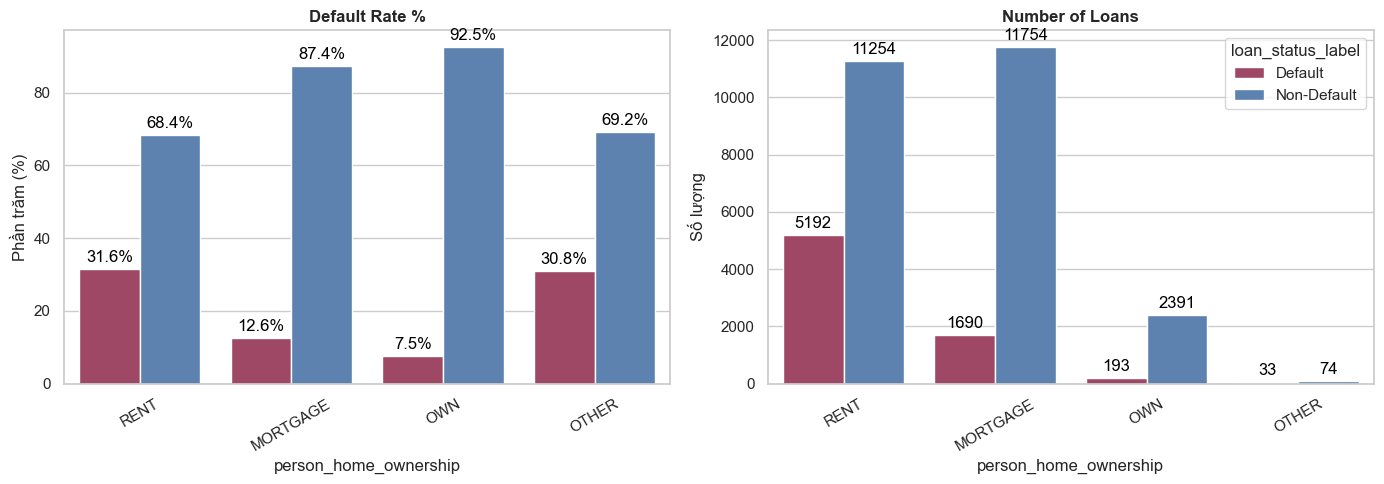

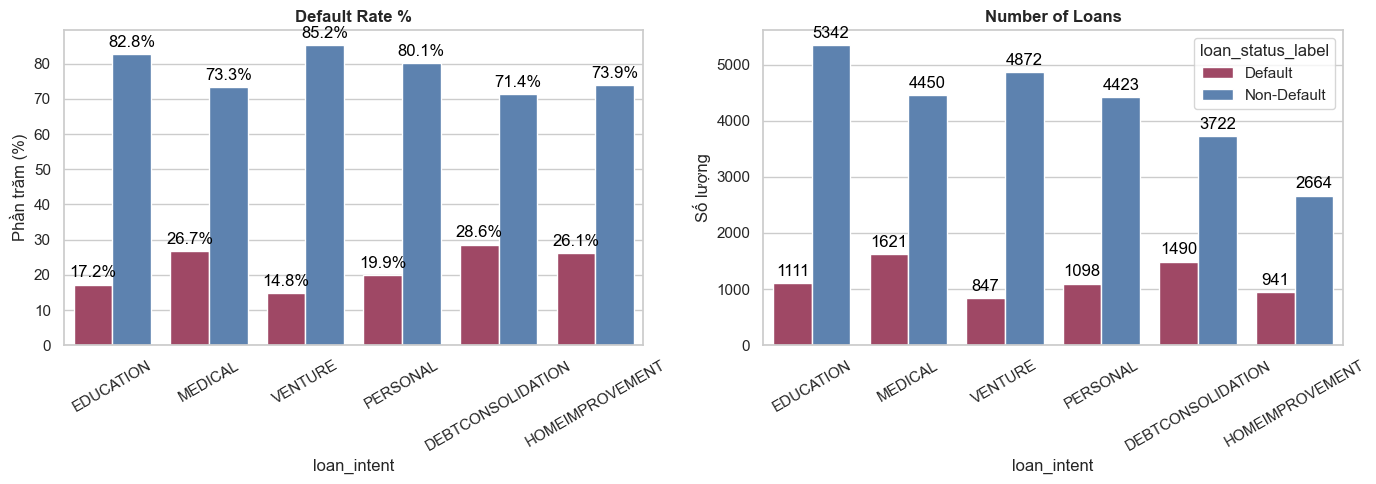

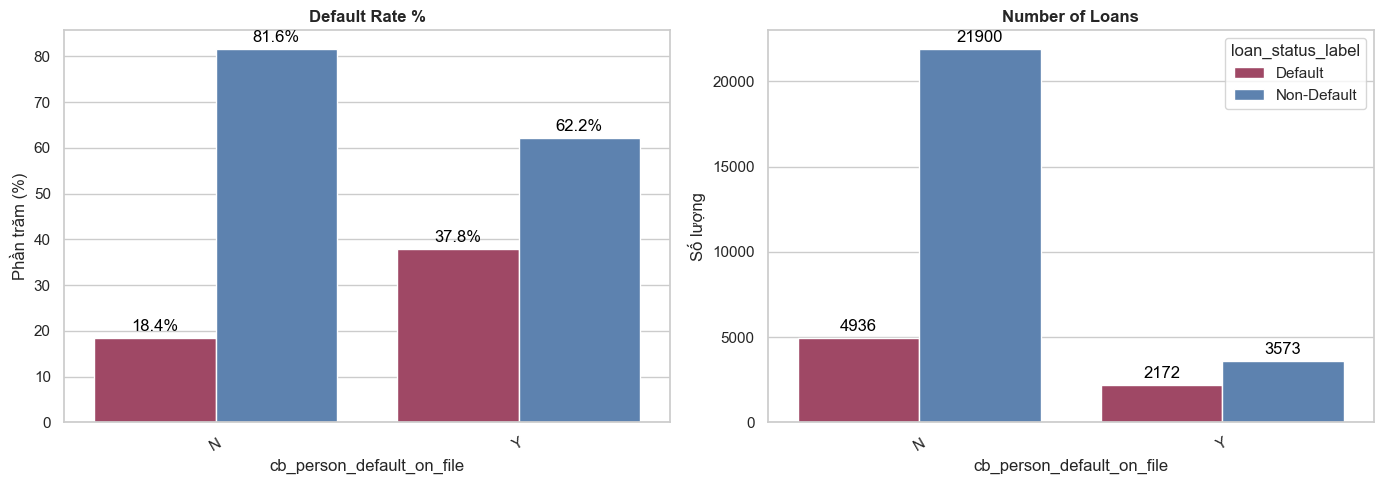

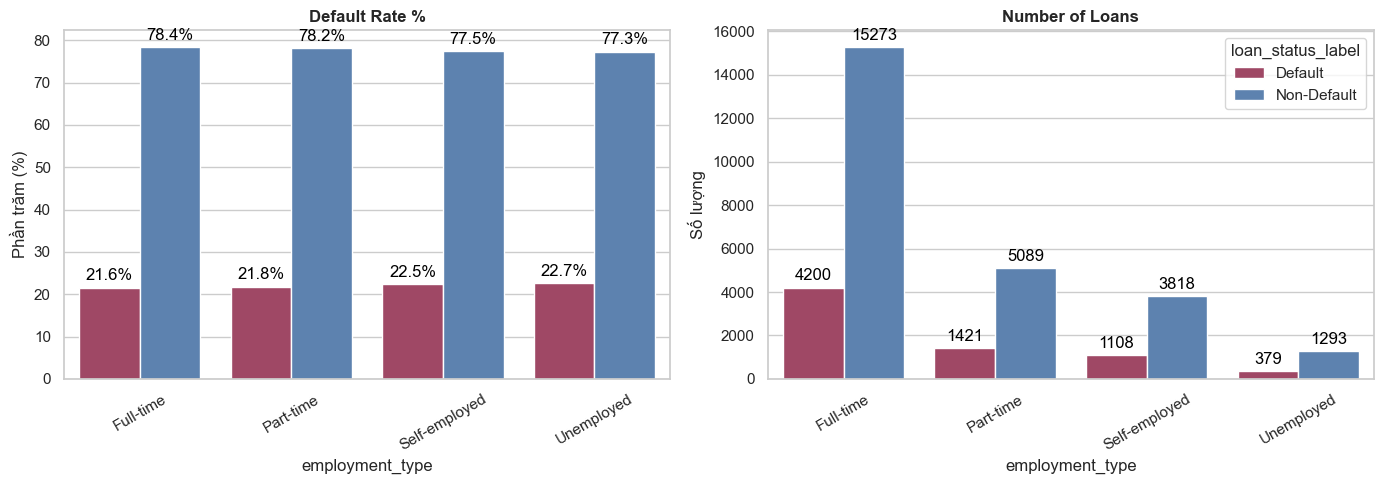

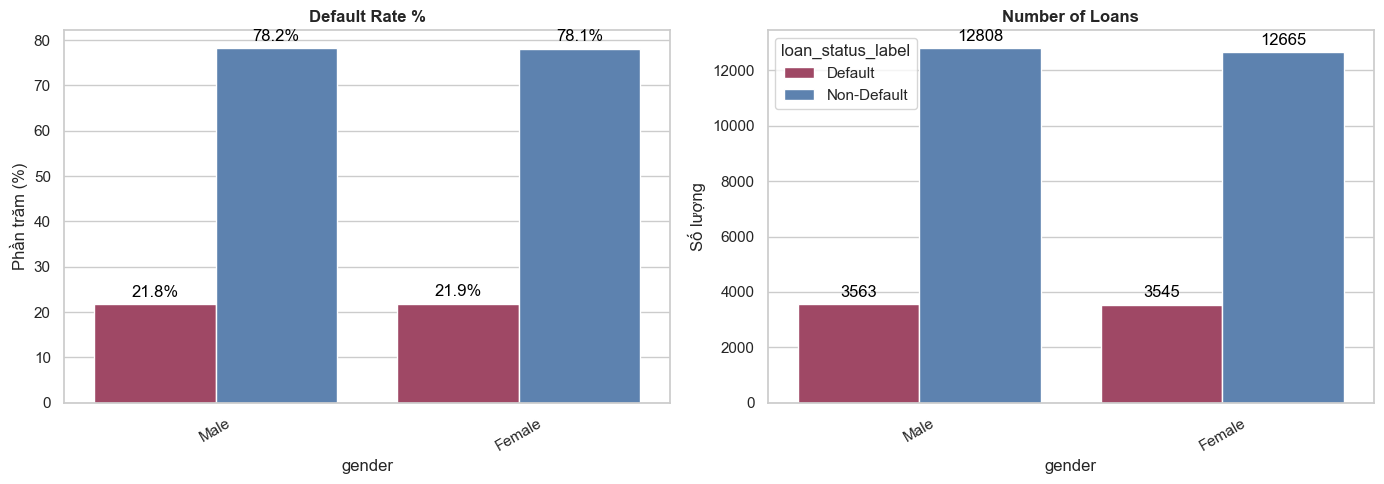

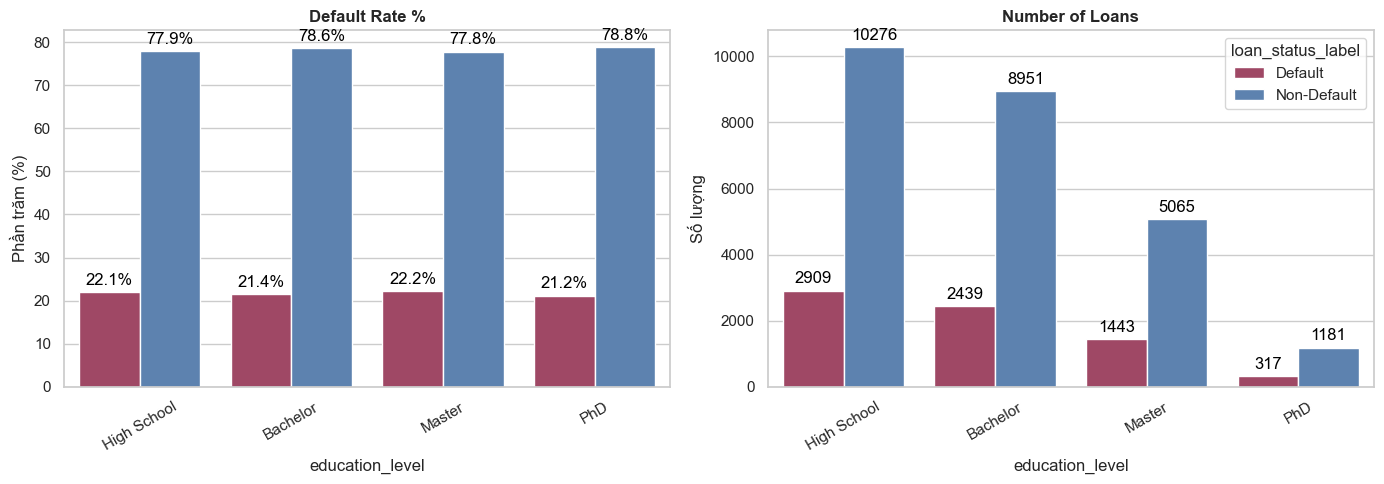

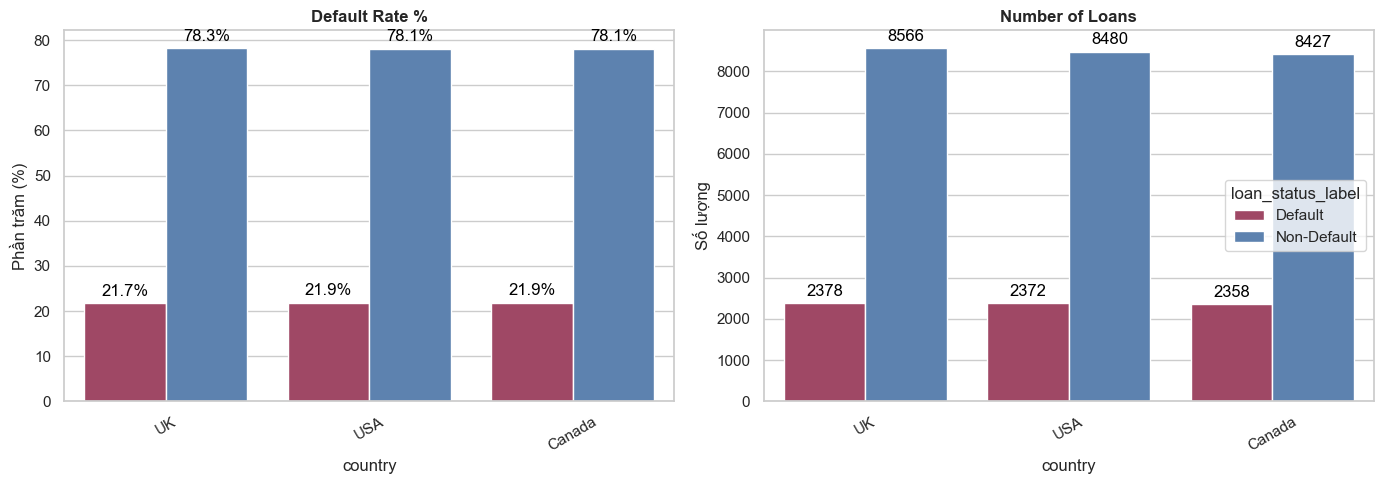

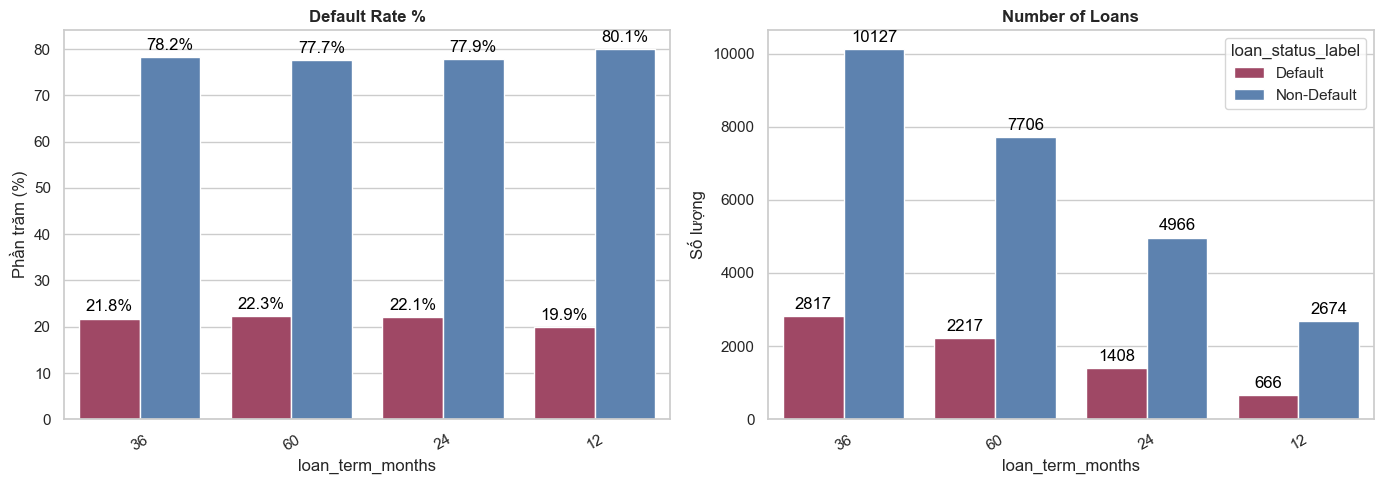

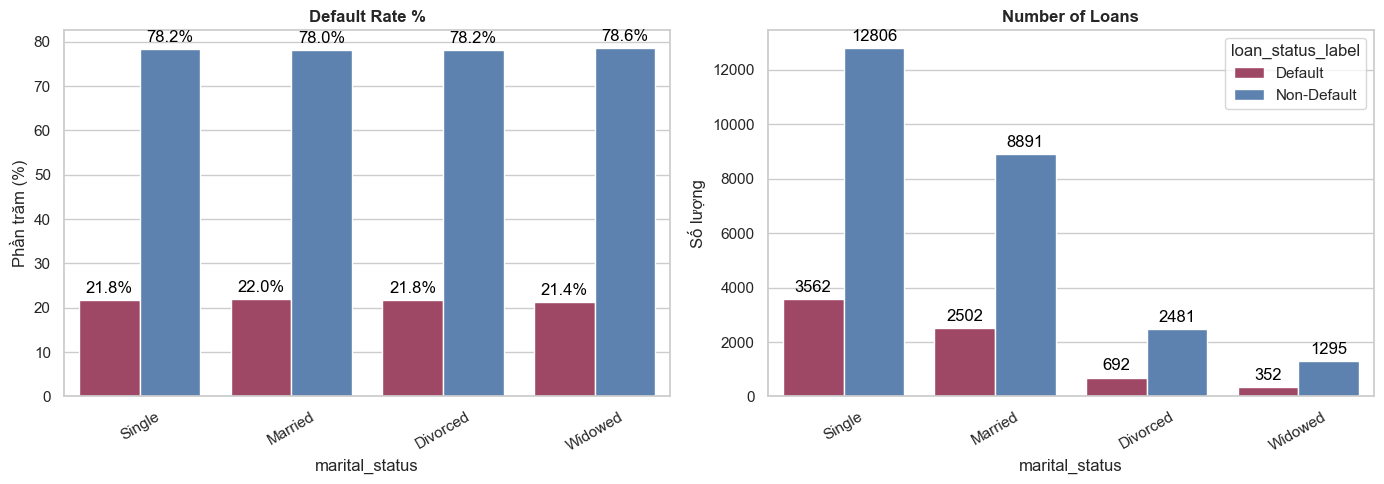

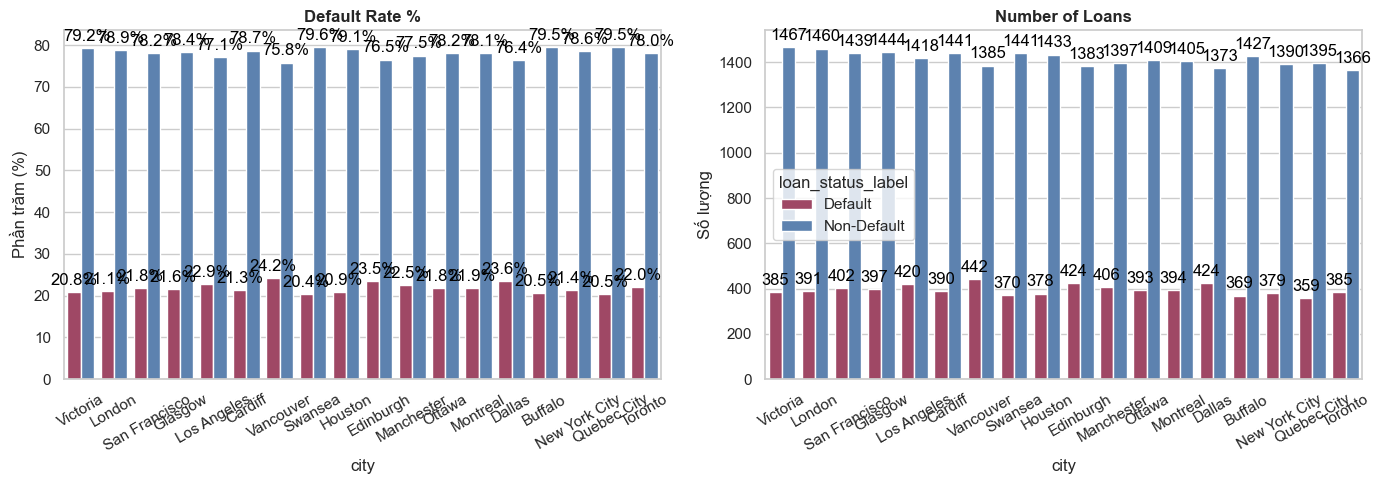

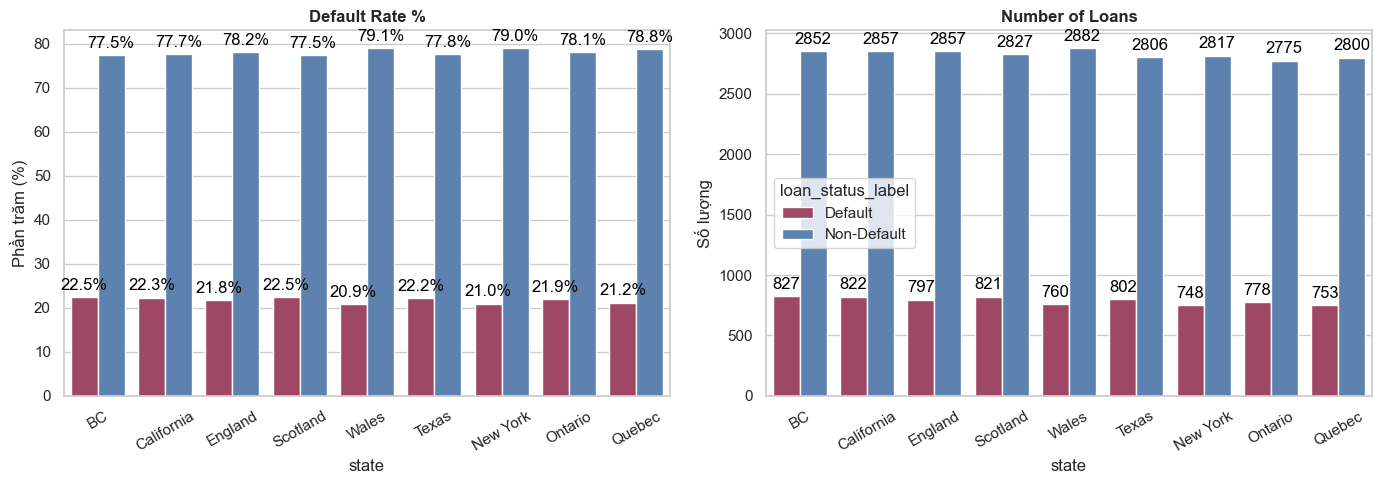

In [16]:
default_rate = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file",
    "employment_type",
    "gender",
    "education_level",
    "country",
    "loan_term_months",
    "marital_status",
    "city",
    "state",
]

colors = ["#AD3960", "#4F81BD"]
for col in default_rate:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    #  Bảng Số Lượng
    count_df = df.groupby(col)['loan_status_label'].value_counts().reset_index(name='Count')
    
    # Tính Bảng Phần Trăm để tự động chia tỷ lệ
    percent_df = df.groupby(col)['loan_status_label'].value_counts(normalize=True).reset_index(name='Percent')
    percent_df['Percent'] = percent_df['Percent'] * 100 
    sap_xep = df[col].value_counts().index #giảm dần
    hue = ['Default', 'Non-Default']

    # Biểu đồ  (Phần trăm)
    sns.barplot(
        data=percent_df, 
        x=col, 
        y="Percent", 
        hue="loan_status_label", 
        hue_order=hue,
        palette=colors, 
        order=sap_xep,
        ax=axes[0]
    )
    axes[0].set_title(f"Default Rate %", weight="bold", fontsize=12)
    axes[0].set_ylabel("Phần trăm (%)")
    axes[0].set_xlabel(col)
    axes[0].tick_params(axis="x", rotation=30)
    
    if axes[0].get_legend() is not None:
        axes[0].get_legend().remove()
        
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.1f%%", padding=3, color="black")

    # Biểu đồ (Số lượng)
    sns.barplot(
        data=count_df,
        x=col,
        y="Count",
        hue="loan_status_label", 
        hue_order=hue,
        palette=colors, 
        order=sap_xep, 
        ax=axes[1]
    )
    axes[1].set_title(f"Number of Loans", weight="bold", fontsize=12)
    axes[1].set_ylabel("Số lượng")
    axes[1].set_xlabel(col)
    axes[1].tick_params(axis="x", rotation=30)

    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%d", padding=3, color="black")


    plt.tight_layout()
    plt.show()
    plt.close()

## Categorical Feature Insights
-  person_home_ownership: Người thuê nhà (RENT) là nhóm rủi ro cao nhất (~32% default)  và OTHER có số lượng vay thấp mà tỷ lệ rủi ro rất cao  trong khi người sở hữu nhà (đặc biệt OWN ~7%) là an toàn nhất , Với nhóm OWN, có thể xem xét nới lỏng điều kiện lãi suất vì rủi ro thực tế thấp hơn đáng kể so với các nhóm còn lại. 
- Loan_Intent: Khách hàng vay mục đích EDUCATION có default rate 18.2%, thấp hơn PERSONAL (26.4%). Điều này có thể do education loans thường có kỳ hạn dài hơn và người vay có định hướng thu nhập rõ ràng hơn. Recommendation nên ưu tiên xét duyệt education loans với điều khoản linh hoạt hơn." 
- Cb_Person_Default_On_File:Khách hàng từng có lịch sử default (Y) có default rate 37.8%, cao hơn gấp đôi so với nhóm không có lịch sử (N: 18.4%).Dự báo khả năng default tiếp tục của họ rất cao, ưu tiên thêm những biện pháp bảo lãnh với loại khách hàng này.
- Employment_Type: Gần như giống nhau (~22–23%), không có tác động đáng kể.không nên dùng employment_type như một tiêu chí phân biệt chính.
- Gender: Tỷ lệ default gần như giống nhau (~22%),  không có khả năng dự báo
- Education_Level: Default rate dao động trong khoảng rất hẹp — High School (22.1%), Bachelor (21.4%), Master (22.2%), PhD (21.2%). Không có xu hướng tuyến tính nào giữa trình độ học vấn và khả năng trả nợ.
- Country: UK (21.7%), USA (21.9%), Canada (21.9%) — ba quốc gia gần như đồng đều tuyệt đối. Số lượng khoản vay cũng được phân bổ rất đều: UK 10,944, USA 10,852, Canada 10,785.
- Past_Delinquencies:  Default rate dao động rất nhỏ từ 0 lần (21.8%) đến 5 lần (25.0%), không có sự phân bố rõ ràng qua những lần trả chậm.

## Phân tích đa biến.

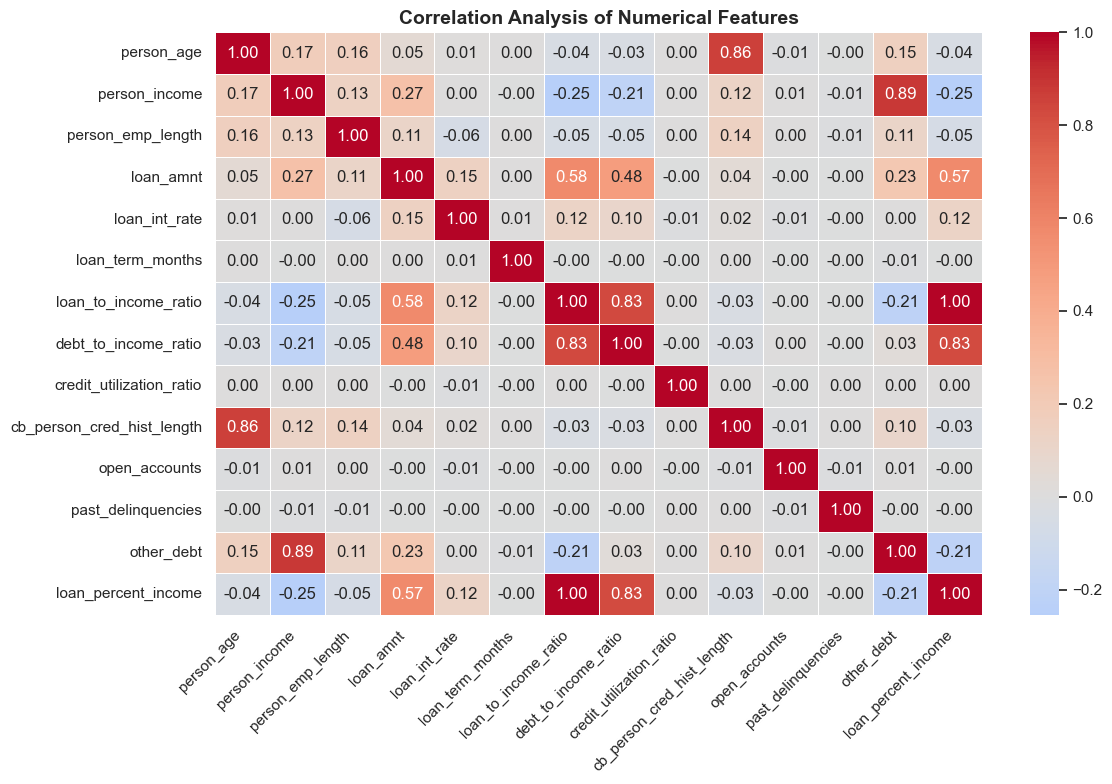

In [18]:

# Chọn các biến số để phân tích tương quan
corr_cols = [
   "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_term_months",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "credit_utilization_ratio",
    "cb_person_cred_hist_length",
    "open_accounts",
    "past_delinquencies",
    "other_debt", 
    "loan_percent_income" 
]
# Tạo bảng tương quan
corr_matrix = df[corr_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        
    cmap="coolwarm",   
    fmt=".2f",         
    center=0,           
    linewidths=0.5
)

plt.title("Correlation Analysis of Numerical Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## corelation feature 
- Có tương quan rất mạnh giữa loan_percent_income và loan_to_income_ratio (~1.00), xác nhận rằng hai biến này bị trùng thông tin và gần như mang nội dung giống nhau.
- Biến debt_to_income_ratio có tương quan mạnh (~0.83) với cả loan_percent_income và loan_to_income_ratio, cho thấy sự chồng lấn thông tin về rủi ro tài chính. 
- person_income và other_debt cũng có tương quan cao (~0.89), cho thấy những người có thu nhập cao thường đi kèm với mức nợ tuyệt đối cao hơn.
- Mối quan hệ mạnh giữa person_age và cb_person_cred_hist_length (~0.86) phản ánh thực tế rằng người lớn tuổi thường có lịch sử tín dụng dài hơn.
- Tồn tại tương quan mức trung bình giữa loan_amnt và các tỷ lệ tài chính (~0.48–0.58), cho thấy các khoản vay lớn hơn thường đi kèm với gánh nặng tài chính cao hơn
- phần lớn các biến là độc lập, vẫn tồn tại một số nhóm biến có tương quan cao, cho thấy khả năng xảy ra đa cộng tuyến (multicollinearity), cần được xử lý thông qua lựa chọn hoặc biến đổi đặc trưng.  


## tỷ lệ default của nhóm missing

,column,missing_count,missing_percent,default_rate_missing
1,loan_int_rate,3116,9.563856,20.667522
0,person_emp_length,895,2.747000,31.508380


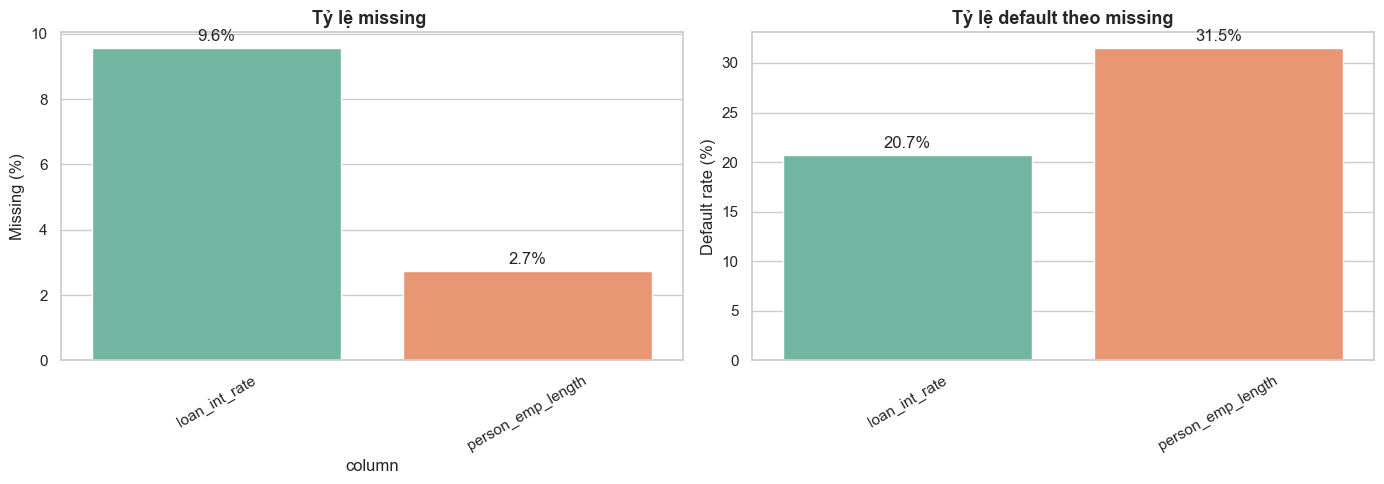

In [19]:
missing_data = []

for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        missing_percent = missing_count / len(df) * 100
        
        # Tính default rate của riêng nhóm bị missing ở cột đó
        default_rate_missing = df[df[col].isnull()]["loan_status"].mean() * 100
        
        #danh sách list cần thêm
        missing_data.append({
            "column": col,
            "missing_count": missing_count,
            "missing_percent": missing_percent,
            "default_rate_missing": default_rate_missing
        })

missing_df = pd.DataFrame(missing_data)
missing_df = missing_df.sort_values(by="missing_count", ascending=False)

display(missing_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = sns.barplot(
    data=missing_df,
    x="column",
    y="missing_percent",
    hue="column",
    palette="Set2",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Tỷ lệ missing ", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Missing (%)")
axes[0].tick_params(axis="x", rotation=30)

# Gắn nhãn % missing trên đầu cột
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%", padding=3)

ax2 = sns.barplot(
    data=missing_df,
    x="column",
    y="default_rate_missing",
    hue="column",
    palette="Set2",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Tỷ lệ default theo missing", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Default rate (%)")
axes[1].tick_params(axis="x", rotation=30)

for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


INSIGHT  
- dù tỷ lệ missing chỉ chiếm 9,6% với loan_int_rate và 2,7% so với person_emp_lenght nhưng nhóm khách missing với person_emp_length có tỷ lệ default lên tới 31.51%, cao hơn đáng kể so với nhóm bị thiếu loan_int_rate là 20.67%. Điều này cho thấy việc thiếu thông tin về thời gian làm việc có thể không hoàn toàn ngẫu nhiên, mà có thể liên quan đến mức độ rủi ro của khách hàng.
- phải xử lý missing ở hai biến thật cẩn thận vì có thể liên quan đến rủi ro.

## BAND ANALYST

In [14]:
# Income band
df["income_band"] = pd.cut(
    df["person_income"],
    bins=[0, 30000, 60000, 100000, 200000, float("inf")],
    labels=["< 30K", "30–60K", "60–100K", "100–200K", "200K+"],
    include_lowest=True
)

# Age band
df["age_band"] = pd.cut(
    df["person_age"],
    bins=[18, 23, 30, 36, 40, 50, 60, float("inf")],
    labels=["18–23", "24–30", "31–36", "37–40", "41–50", "51–60", "61+"],
    include_lowest=True
)

# LTI band
df["lti_band"] = pd.cut(
    df["loan_to_income_ratio"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, float("inf")],
    labels=["0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.4", "0.4–0.5", "0.5+"],
    include_lowest=True
)

# DTI band
df["dti_band"] = pd.cut(
    df["debt_to_income_ratio"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, float("inf")],
    labels=["0–0.2", "0.2–0.4", "0.4–0.6", "0.6–0.8", "0.8+"],
    include_lowest=True
)

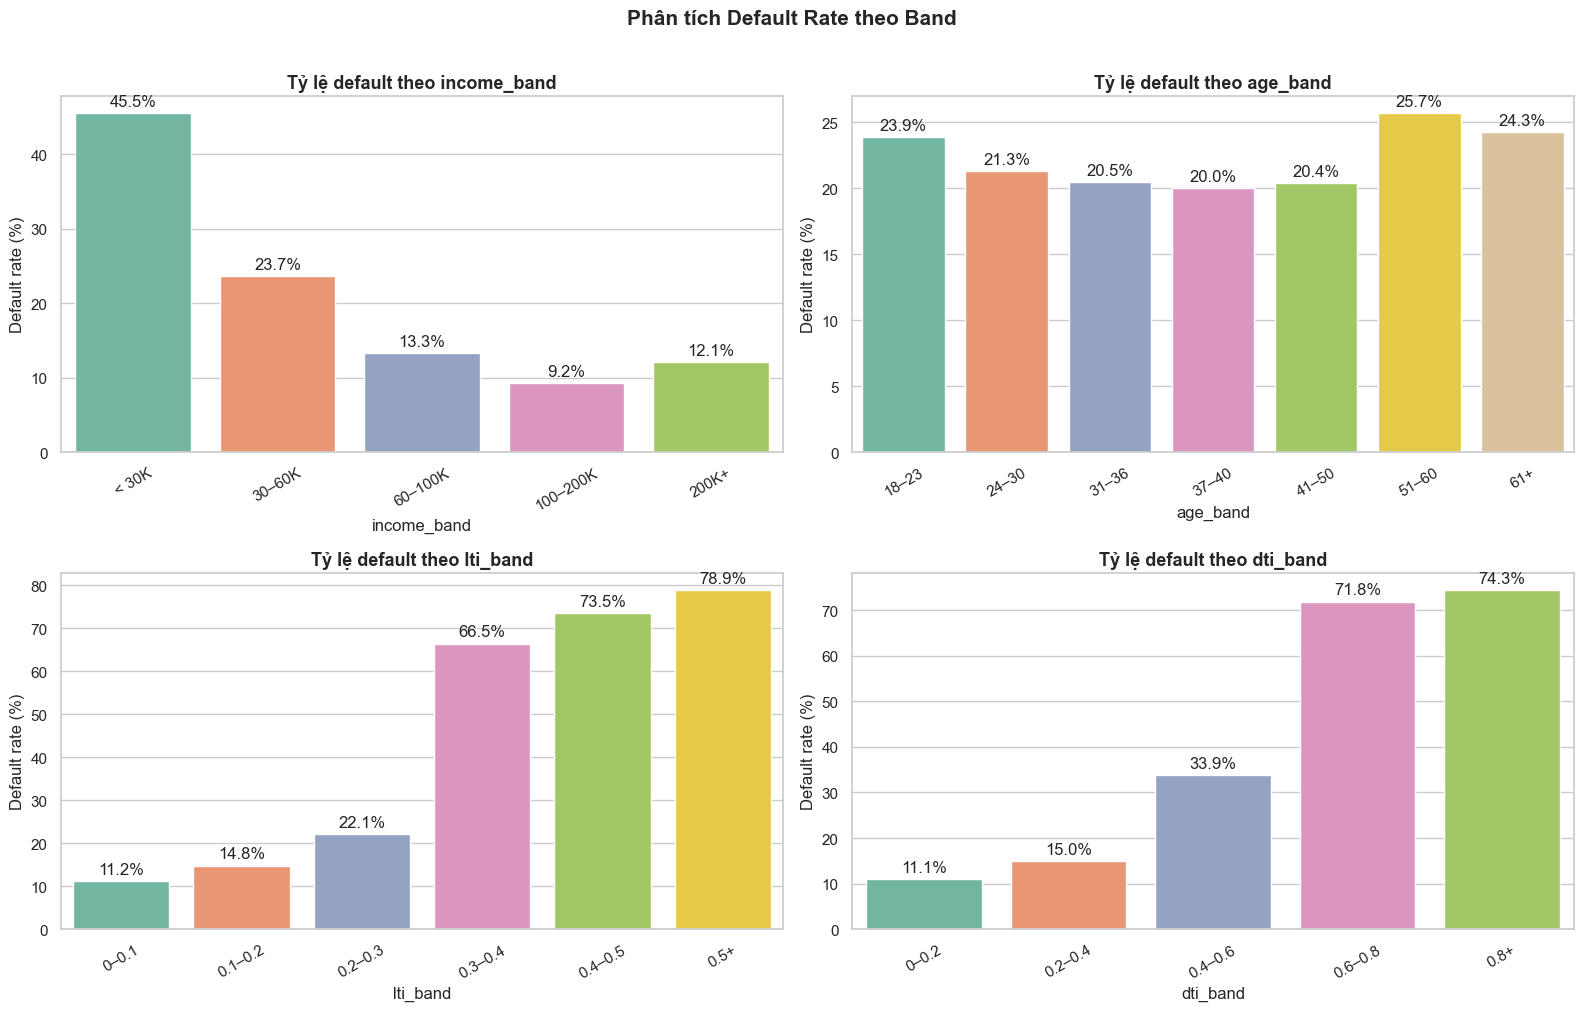

In [ ]:
band_columns = ["income_band", "age_band", "lti_band", "dti_band"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(band_columns):
    band_summary = (
        df.groupby(col, observed=True)["loan_status"]
        .agg(["count", "mean"])
        .reset_index()
    )
    band_summary["default_rate_pct"] = band_summary["mean"] * 100

    ax = axes[i]
    sns.barplot(
        data=band_summary,
        x=col,
        y="default_rate_pct",
        hue=col,
        palette="Set2",
        legend=False,
        dodge=False,
        ax=ax
    )

    ax.set_title(f"Tỷ lệ default theo {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Default rate (%)")
    ax.tick_params(axis="x", rotation=30)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

fig.suptitle("Phân tích Default Rate theo Band", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

INSIGHT  
- LTI_band: tỷ lệ default được thể hiện rõ ràng qua một ngưỡng nhất định (~0,3). Khách hàng vay số tiền vượt quá 30% thu nhập hàng năm có xác suất vỡ nợ tăng gần gấp 3 lần so với nhóm dưới ngưỡng này.Nên cân nhắc lại điều khoản cho vay với những khách hàng thuộc nhóm này.
- DTI_band: DTI có pattern tương tự LTI — tỷ lệ default tăng dần theo từng mốc  đặc biệt là từ 
(0,4 đến 0,6 trở đi),default rate của band 0.8+ (74.3%) gần bằng band 0.6–0.8 (71.8%), cho thấy khi DTI đã vượt 0.6 thì rủi ro đã bão hòa — tăng thêm nợ không làm tình hình tệ hơn nhiều vì đã ở mức nguy hiểm tối đa.
- income_band: Thu nhập tăng thì default rate giảm, từ 39.7% (Thấp) xuống 8.7% (Cực kỳ cao). Đây là pattern tự nhiên và có ý nghĩa kinh tế — người thu nhập cao có khả năng trả nợ tốt hơn.  
- age_band:  Default rate có hình chữ U — cao ở người trẻ (23.9%), thấp nhất ở trung niên 37–40 (20.0%), rồi tăng trở lại ở người lớn tuổi (27.0%). Đây là pattern có ý nghĩa kinh tế: người trẻ ít kinh nghiệm tài chính, người già có thể gặp vấn đề sức khỏe hoặc thu nhập sau nghỉ hưu giảm.   
=> Các biến tài chính liên quan đến khả năng trả nợ, đặc biệt là loan_to_income_ratio và debt_to_income_ratio, có mối quan hệ rất rõ với khả năng default. Khi áp lực khoản vay và tổng nợ trên thu nhập tăng, tỷ lệ default tăng mạnh. Ngoài ra, nhóm khách hàng có thu nhập thấp cũng thể hiện mức rủi ro cao hơn đáng kể

## OVERALL
- loan_int_rate : Lãi suất cao cho thấy khách hàng rủi ro cao hơn → tín hiệu mạnh về khả năng vỡ nợ.
- debt_to_income_ratio :Yếu tố rủi ro cốt lõi  khách hàng có gánh nặng tài chính cao có khả năng default lớn hơn nhiều.
- loan_percent_income :
Áp lực trả nợ rất quan trọng  tỷ lệ vay trên thu nhập cao làm tăng rủi ro default.
- person_income:
Thu nhập cao = khách hàng an toàn hơn ,chỉ báo mạnh về khả năng trả nợ.
- person_home_ownership:
Ổn định nhà ở có ý nghĩa,  người thuê nhà rủi ro hơn, trong khi người sở hữu nhà an toàn hơn đáng kể.
- cb_person_default_on_file:
Hành vi quá khứ dự báo rủi ro tương lai , khách hàng từng default có khả năng default lại cao hơn nhiều
- loan_intent: 
Mục đích vay ảnh hưởng đến rủi ro → debt consolidation và medical rủi ro hơn; education và venture an toàn hơn.
- loan_amnt:
Khoản vay lớn làm tăng mức độ rủi ro → tỷ lệ default cao hơn nhẹ.
- loan_to_income_ratio:
Trùng tín hiệu với loan_percent_income → thông tin tương tự, nên giữ một biến để tránh dư thừa.
- person_age:
Tác động kinh doanh thấp → hành vi default khá giống nhau giữa các nhóm tuổi.
- person_emp_length:
Tín hiệu ổn định yếu → thời gian làm việc dài hơn chỉ làm giảm rủi ro nhẹ, nhưng không đáng kể.
- cb_person_cred_hist_length:
Ít hữu ích → độ dài lịch sử tín dụng đơn lẻ không giải thích tốt default.
- open_accounts:
Không có tác động đáng kể → hành vi tương tự giữa các nhóm.
- credit_utilization_ratio:
Không có tín hiệu rõ ràng → không phân biệt được hành vi defaul
- past_delinquencies:
Biến dự báo yếu → ít thông tin hơn so với cờ prior default.
- gender / marital_status / education_level / country / state / city:	Không có tác động kinh doanh rõ ràng → tỷ lệ default tương đối nhất quán giữa các nhóm nhân khẩu học và địa lý.